
# Geometría de Berry y Uhlmann de estados coherentes fotón‑añadidos entrelazados
### Holonomía controlada por la concurrencia y singularidades nodales

**Notebook de acompañamiento** al artículo *"Berry and Uhlmann Geometry of
Entangled Photon-Added Coherent States: Concurrence-Controlled Holonomy and
Nodal Singularities"* (F. Nieto-Guadarrama, 2026).

Este notebook:

1. Implementa **todas** las fórmulas analíticas del artículo (fase de Berry
   de un PACS individual, fase de Berry global del estado bipartito
   entrelazado, concurrencia, población reducida, fase de Uhlmann y sus
   singularidades nodales).
2. **Deduce con más detalle** los pasos intermedios que el artículo condensa
   (en particular, la expansión de Fock de los solapamientos ⟨α,m|α,n⟩ y del
   elemento de matriz cruzado ⟨α,m|a†a|α,n⟩, Apéndices A y B), y **corrige
   explícitamente** una ambigüedad de la Ec. (27)/(37) del manuscrito
   original (el factor $\Delta!$ debe ir *fuera* de la raíz cuadrada, no
   dentro como $\sqrt{\Delta!}$) — la corrección se verifica numéricamente
   hasta precisión de máquina.
3. **Valida cada fórmula cerrada contra un cálculo independiente "exacto"**
   construido en el espacio de Fock truncado (sin usar funciones
   hipergeométricas), y contra las Tablas I y II publicadas en el artículo.
4. Reproduce las **7 figuras** y las **2 tablas** del artículo, con
   generación en pantalla y guardado individual en PDF vectorial listo para
   publicación (carpeta `figures/`).

Cada rutina incluye una docstring que indica de qué ecuación del artículo
proviene y qué representa físicamente.


In [1]:

# ============================================================
# Celda 1 — Importaciones y configuración gráfica
# ============================================================
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import eval_genlaguerre, hyp1f1, gammaln
from scipy.optimize import brentq

# Carpeta de salida para las figuras en PDF (vectorial, apto para LaTeX/Overleaf)
FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

# Estilo "de publicación": fuente serif tipo LaTeX, tamaños legibles, rejilla suave.
plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,        # resolución en pantalla
    "savefig.dpi": 300,       # resolución si se exporta a raster
    "axes.grid": True,
    "grid.alpha": 0.3,
    "mathtext.fontset": "cm", # símbolos matemáticos estilo Computer Modern (LaTeX)
    "font.family": "serif",
})

def savefig(fig, name):
    """Guarda la figura activa como PDF vectorial en FIGDIR/<name>.pdf
    y también la deja mostrada en pantalla (no cierra la figura)."""
    path = os.path.join(FIGDIR, name + ".pdf")
    fig.savefig(path, bbox_inches="tight")
    print(f"[guardado] {path}")

MU_BAL = 1 / np.sqrt(2)   # peso balanceado mu = nu = 1/sqrt(2) usado en varias figuras
print("Entorno listo.")


Entorno listo.



## 1. Funciones especiales: polinomios de Laguerre

El artículo utiliza el polinomio de Laguerre estándar $L_n(x)$ (caso
particular $\alpha=0$ del polinomio de Laguerre generalizado
$L_n^{(\alpha)}(x)$), evaluado en argumentos **negativos** $x=-|\alpha|^2$
para construir la normalización de los PACS. Usamos la implementación
robusta de `scipy.special.eval_genlaguerre`.


In [2]:

# ============================================================
# Celda 2 — Polinomio de Laguerre L_n(x)
# ============================================================
def laguerre(n, x):
    """Polinomio de Laguerre estándar L_n(x) = L_n^{(0)}(x).

    Aparece en el artículo, p.ej. en la normalización de los PACS,
    Ec. (4): |alpha,n> ~ 1/sqrt(n! L_n(-|alpha|^2)).
    """
    return eval_genlaguerre(n, 0, x)

# Comprobación rápida contra las expresiones cerradas de bajo orden
# L_0(x)=1, L_1(x)=1-x, L_2(x)=(x^2-4x+2)/2
x_test = 0.7
assert abs(laguerre(0, x_test) - 1) < 1e-12
assert abs(laguerre(1, x_test) - (1 - x_test)) < 1e-12
assert abs(laguerre(2, x_test) - (x_test**2 - 4*x_test + 2)/2) < 1e-12
print("Polinomios de Laguerre verificados contra fórmulas cerradas de bajo orden.")


Polinomios de Laguerre verificados contra fórmulas cerradas de bajo orden.



## 2. Estados coherentes fotón‑añadidos (PACS) — Sección II del artículo

### 2.1 Definición y expansión de Fock

El PACS se define aplicando $n$ veces el operador de creación sobre un
estado coherente de Glauber $|\alpha\rangle$ y renormalizando:

$$
|\alpha,n\rangle = \frac{a^{\dagger n}|\alpha\rangle}{\big[\langle\alpha|a^n a^{\dagger n}|\alpha\rangle\big]^{1/2}}.
\tag{2}
$$

**Derivación detallada de la expansión de Fock (Ec. 4).** Partiendo de
$|\alpha\rangle=e^{-|\alpha|^2/2}\sum_j \alpha^j/\sqrt{j!}\,|j\rangle$ y usando
$a^{\dagger n}|j\rangle=\sqrt{(j+1)(j+2)\cdots(j+n)}\,|j+n\rangle=\sqrt{(j+n)!/j!}\,|j+n\rangle$,

$$
a^{\dagger n}|\alpha\rangle = e^{-|\alpha|^2/2}\sum_{j=0}^{\infty}
\frac{\alpha^{j}}{\sqrt{j!}}\sqrt{\frac{(j+n)!}{j!}}\,|j+n\rangle
= e^{-|\alpha|^2/2}\sum_{k=0}^{\infty} \frac{\alpha^{k}\sqrt{(n+k)!}}{k!}\,|n+k\rangle ,
$$

donde se renombró $k\equiv j$. La norma al cuadrado de este vector no
normalizado es exactamente $\langle\alpha|a^n a^{\dagger n}|\alpha\rangle
= n!\,L_n(-|\alpha|^2)$ (identidad estándar de los PACS de Agarwal–Tara
[1]), de modo que

$$
|\alpha,n\rangle = \frac{e^{-|\alpha|^2/2}}{\sqrt{n!\,L_n(-|\alpha|^2)}}
\sum_{k=0}^{\infty}\frac{\alpha^{k}\sqrt{(n+k)!}}{k!}\,|n+k\rangle ,
\tag{4}
$$

que es exactamente la Ec. (4) del artículo. Esta expansión se implementa
abajo (`pacs_fock_amplitudes`) y sirve como "cálculo exacto" (espacio de
Fock truncado) contra el cual se **validan todas las fórmulas cerradas**
del resto del notebook — una capa de verificación numérica que el
manuscrito original no incluye explícitamente.

### 2.2 Fase de Berry de un PACS individual

Bajo la rotación de número $U(\phi)=e^{-ia^\dagger a\,\phi}$ (Ec. 5), la
conexión de Berry es simplemente el número medio de fotones,

$$
\mathcal{A}_\phi = i\langle\alpha,n|U^\dagger(\phi)\partial_\phi U(\phi)|\alpha,n\rangle
= \langle\alpha,n|a^\dagger a|\alpha,n\rangle \equiv \bar n_{\alpha,n},
\tag{6-7}
$$

**Detalle del paso 6→7:** $U^\dagger(\phi)\partial_\phi U(\phi) = U^\dagger(\phi)(-ia^\dagger a)U(\phi) = -ia^\dagger a$
(el operador número conmuta con cualquier función de sí mismo, en
particular con $U(\phi)=e^{-ia^\dagger a\phi}$), de modo que
$\mathcal A_\phi = i\langle\alpha,n|(-ia^\dagger a)|\alpha,n\rangle = \langle\alpha,n|a^\dagger a|\alpha,n\rangle$.

Como $\mathcal A_\phi$ no depende de $\phi$ (el generador es diagonal en
la base de Fock, y $|\alpha,n\rangle$ es un autoestado *instantáneo* con
valor esperado constante bajo esta evolución particular), la integral
cíclica es trivial:

$$
\Phi_B^{(n)} = \int_0^{2\pi}\mathcal A_\phi\,d\phi = 2\pi\,\bar n_{\alpha,n}.
\tag{9}
$$

El número medio de fotones se obtiene de la relación de recurrencia de
Laguerre aplicada a la Ec. (4):

$$
\bar n_{\alpha,n} = (n+1)\,\frac{L_{n+1}(-|\alpha|^2)}{L_n(-|\alpha|^2)} - 1.
\tag{8}
$$


In [3]:

# ============================================================
# Celda 3 — Sección II: PACS individual
# ============================================================
def mean_photon_number(alpha, n):
    """Numero medio de fotones n-barra_{alpha,n}, Ec. (8).
    Cociente de polinomios de Laguerre consecutivos evaluados en -alpha^2."""
    x = alpha**2
    return (n + 1) * laguerre(n + 1, -x) / laguerre(n, -x) - 1.0

def berry_phase_single(alpha, n):
    """Fase de Berry ciclica de un PACS individual, Ec. (9):
    Phi_B^{(n)} = 2*pi*n-barra_{alpha,n}."""
    return 2 * np.pi * mean_photon_number(alpha, n)

# Sanity check: para n=0 (estado coherente ordinario) n-barra debe -> |alpha|^2
for a in [0.3, 1.0, 2.0]:
    print(f"alpha={a}:  nbar(n=0)={mean_photon_number(a,0):.6f}  (esperado |alpha|^2={a**2:.6f})")


alpha=0.3:  nbar(n=0)=0.090000  (esperado |alpha|^2=0.090000)
alpha=1.0:  nbar(n=0)=1.000000  (esperado |alpha|^2=1.000000)
alpha=2.0:  nbar(n=0)=4.000000  (esperado |alpha|^2=4.000000)



## 3. Verificación numérica "exacta": espacio de Fock truncado

Para poder afirmar con confianza que las fórmulas cerradas (hipergeométricas)
usadas más adelante son correctas, construimos aquí, **directamente desde
la Ec. (4)**, los coeficientes de Fock de $|\alpha,n\rangle$ con un corte
$N_{\rm cut}$ suficientemente grande, y calculamos cualquier producto
interno o valor esperado por suma explícita. Esto no depende de ninguna
identidad hipergeométrica y sirve como "ground truth" (verdad numérica) de
referencia.


In [4]:

# ============================================================
# Celda 4 — Amplitudes de Fock exactas y validador de normalizacion
# ============================================================
def pacs_fock_amplitudes(alpha, n, Ncut):
    """Coeficientes c_k (k=0..Ncut-1) de |alpha,n> = sum_k c_k |n+k>,
    calculados directamente de la Ec. (4) en espacio logaritmico para
    evitar desbordamientos con n,k grandes."""
    x = alpha**2
    Ln = laguerre(n, -x)
    norm = np.exp(-x / 2) / np.sqrt(math.factorial(n) * Ln)
    k = np.arange(Ncut)
    logc = k * np.log(np.abs(alpha) + 1e-300) + 0.5 * gammaln(n + k + 1) - gammaln(k + 1)
    return norm * np.sign(alpha) ** k * np.exp(logc)

def _align(alpha, m, n, Ncut):
    """Coloca los coeficientes de |alpha,m> y |alpha,n> en un mismo
    arreglo indexado por el nivel de Fock, para poder sumarlos termino
    a termino (necesario porque cada PACS empieza en un nivel distinto)."""
    cm_ = pacs_fock_amplitudes(alpha, m, Ncut)
    cn_ = pacs_fock_amplitudes(alpha, n, Ncut)
    fock_max = Ncut + max(m, n)
    vm = np.zeros(fock_max); vn = np.zeros(fock_max)
    vm[m:m + Ncut] = cm_
    vn[n:n + Ncut] = cn_
    return vm, vn

def overlap_fock(alpha, m, n, Ncut=400):
    """<alpha,m|alpha,n> por suma directa en espacio de Fock (sin 1F1)."""
    vm, vn = _align(alpha, m, n, Ncut)
    return np.sum(vm * vn)

def kappa_fock(alpha, m, n, Ncut=400):
    """<alpha,m| a^dagger a |alpha,n> por suma directa (a^dagger a |l> = l|l>)."""
    vm, vn = _align(alpha, m, n, Ncut)
    levels = np.arange(len(vm))
    return np.sum(vm * levels * vn)

# La normalizacion de cada PACS debe dar exactamente 1:
for (alpha, n) in [(0.5,0), (1.3,2), (2.7,4)]:
    nrm = overlap_fock(alpha, n, n, Ncut=500)
    print(f"<alpha={alpha},n={n}|alpha={alpha},n={n}> = {nrm:.10f}  (debe ser 1)")


<alpha=0.5,n=0|alpha=0.5,n=0> = 1.0000000000  (debe ser 1)
<alpha=1.3,n=2|alpha=1.3,n=2> = 1.0000000000  (debe ser 1)
<alpha=2.7,n=4|alpha=2.7,n=4> = 1.0000000000  (debe ser 1)



## 4. Apéndice A: solapamientos de PACS y funciones hipergeométricas

### 4.1 Cálculo detallado (más explícito que el artículo original)

Queremos $\langle\alpha,m|\alpha,n\rangle$ para $n\ge m$. Insertando la
expansión de Fock (Ec. 4) de cada bra/ket y usando la ortogonalidad de
Fock, sólo sobreviven los términos con nivel de Fock común
$\ell=m+j=n+k$ (es decir $j=\ell-m$, $k=\ell-n$, válido para $\ell\ge n$):

$$
\langle\alpha,m|\alpha,n\rangle = A_mA_n\sum_{\ell=n}^{\infty}
\frac{(\alpha^*)^{\ell-m}\sqrt{\ell!}}{(\ell-m)!}\cdot\frac{\alpha^{\ell-n}\sqrt{\ell!}}{(\ell-n)!},
\qquad A_n\equiv\frac{e^{-|\alpha|^2/2}}{\sqrt{n!\,L_n(-|\alpha|^2)}}.
$$

Para $\alpha$ real y escribiendo $\ell=n+p$ ($p=0,1,2,\dots$), $\Delta\equiv n-m$:

$$
\langle\alpha,m|\alpha,n\rangle = A_mA_n\,\alpha^{\Delta}
\sum_{p=0}^{\infty}\alpha^{2p}\,\frac{(n+p)!}{(\Delta+p)!\,p!}.
$$

Usando $(n+p)!/(\Delta+p)! = (n!/\Delta!)\,(n+1)_p/(\Delta+1)_p$ (cociente de
factoriales ascendentes de Pochhammer) se reconoce la serie hipergeométrica
confluente:

$$
\sum_{p=0}^{\infty}\frac{(n+1)_p}{(\Delta+1)_p}\frac{x^p}{p!} = {}_1F_1(n+1;\Delta+1;x),
\qquad x=\alpha^2 ,
$$

y por lo tanto, con $A_mA_n = e^{-x}/\sqrt{m!\,n!\,L_m(-x)L_n(-x)}$,

$$
\boxed{\;g_{mn}(\alpha) \equiv \langle\alpha,m|\alpha,n\rangle =
\frac{e^{-x}\,\alpha^{\Delta}\,n!}{\Delta!\,\sqrt{m!\,n!\,L_m(-x)L_n(-x)}}\;
{}_1F_1(n+1;\Delta+1;x)\;}
\tag{27'}
$$

**Nota sobre la Ec. (27) del manuscrito original.** La expresión impresa en
el artículo agrupa el factor $\Delta!$ *dentro* de la raíz cuadrada del
denominador, junto con $n!\,m!\,L_nL_m$. Repitiendo la derivación desde la
Ec. (4) (arriba) se obtiene en cambio $\Delta!$ **fuera** de la raíz, como
en la Ec. (27') recuadrada. Verificamos a continuación, contra la suma
exacta en espacio de Fock y contra la Tabla I publicada, que (27') es la
forma numéricamente correcta (la discrepancia es award de una simple
diferencia de una raíz cuadrada, consistente con una errata tipográfica de
composición al aplanar la fracción en LaTeX/PDF).


In [5]:

# ============================================================
# Celda 5 — Solapamiento cerrado g_mn(alpha), Ec. (27') corregida
# ============================================================
def _prefactor(alpha, m, n):
    """Factor comun a g_mn y kappa_mn (ver Ecs. 27' y 37 en este notebook)."""
    Delta = n - m
    x = alpha**2
    Ln = laguerre(n, -x); Lm = laguerre(m, -x)
    return (np.exp(-x) * alpha**Delta * math.factorial(n)
            / (math.factorial(Delta) * np.sqrt(math.factorial(m) * math.factorial(n) * Ln * Lm)))

def g_mn(alpha, m, n):
    """Solapamiento <alpha,m|alpha,n> para alpha real, cualquier orden de m,n.
    Forma cerrada corregida, Ec. (27'). Ver Celda 4 para la derivacion."""
    if n < m:
        return g_mn(alpha, n, m)          # simetrico bajo m<->n
    if alpha == 0.0:
        return 1.0 if m == n else 0.0
    Delta = n - m
    x = alpha**2
    return _prefactor(alpha, m, n) * hyp1f1(n + 1, Delta + 1, x)

# ---- Validacion contra la suma exacta en espacio de Fock ----
print(f"{'m':>2} {'n':>2} {'alpha':>6}   {'g_mn (cerrada)':>15} {'overlap_fock (exacta)':>22}   diff")
max_diff = 0.0
for (m, n) in [(0,1),(0,2),(0,3),(1,3),(2,4)]:
    for alpha in [0.5, 1.0, 1.7, 2.3]:
        gc = g_mn(alpha, m, n)
        gf = overlap_fock(alpha, m, n, Ncut=500)
        d = abs(gc - gf)
        max_diff = max(max_diff, d)
        print(f"{m:2d} {n:2d} {alpha:6.2f}   {gc:15.8f} {gf:22.8f}   {d:.2e}")
print("\ndiferencia maxima (forma cerrada vs. suma exacta de Fock):", max_diff)
assert max_diff < 1e-8


 m  n  alpha    g_mn (cerrada)  overlap_fock (exacta)   diff
 0  1   0.50        0.44721360             0.44721360   0.00e+00
 0  1   1.00        0.70710678             0.70710678   1.11e-16
 0  1   1.70        0.86193422             0.86193422   1.11e-16
 0  1   2.30        0.91707006             0.91707006   4.44e-16
 0  2   0.50        0.14285714             0.14285714   0.00e+00
 0  2   1.00        0.37796447             0.37796447   5.55e-17
 0  2   1.70        0.61738467             0.61738467   2.22e-16
 0  2   2.30        0.73970389             0.73970389   3.33e-16
 0  3   0.50        0.03755579             0.03755579   6.94e-18
 0  3   1.00        0.17149859             0.17149859   0.00e+00
 0  3   1.70        0.39169305             0.39169305   1.67e-16
 0  3   2.30        0.54352029             0.54352029   3.33e-16
 1  3   0.50        0.21834097             0.21834097   2.78e-17
 1  3   1.00        0.48507125             0.48507125   5.55e-17
 1  3   1.70        0.6880776

In [6]:

# ============================================================
# Celda 6 — Validacion contra la Tabla I publicada (alpha_g)
# ============================================================
def alpha_from_q(qtarget, m, n, upper=15.0):
    """Resuelve |g_mn(alpha)|^2 = qtarget para alpha>0 por biseccion,
    usando que |g_mn(alpha)|^2 crece monotonamente con alpha (Sec. VII.B)."""
    def f(a):
        return g_mn(a, m, n)**2 - qtarget
    a_lo, a_hi = 1e-8, upper
    while f(a_hi) < 0 and a_hi < 1e5:
        a_hi *= 1.5
    return brentq(f, a_lo, a_hi, xtol=1e-12, rtol=1e-13)

def alpha_g(m, n, upper=15.0):
    """Amplitud critica alpha_g(m,n) definida por |g_mn(alpha_g)|^2 = 1/2, Ec. (70)."""
    return alpha_from_q(0.5, m, n, upper)

# Valores publicados en la Tabla I del articulo (n\\m)
table_I_ref = {
    (1,0):1.0000,
    (2,0):2.1094, (2,1):0.7221,
    (3,0):3.2756, (3,1):1.8000, (3,2):0.5921,
    (4,0):4.4576, (4,1):3.0354, (4,2):1.5829, (4,3):0.5135,
    (5,0):5.6464, (5,1):4.2685, (5,2):2.8269, (5,3):1.4235, (5,4):0.4596,
}
print(f"{'n':>2} {'m':>2}  {'calculado':>10} {'Tabla I':>9}   diff")
max_diff = 0.0
for (n, m), ref in table_I_ref.items():
    ag = alpha_g(m, n)
    d = abs(ag - ref)
    max_diff = max(max_diff, d)
    print(f"{n:2d} {m:2d}  {ag:10.4f} {ref:9.4f}   {d:.1e}")
print("\ndiferencia maxima frente a la Tabla I publicada:", max_diff, "(consistente con redondeo a 4 decimales)")


 n  m   calculado   Tabla I   diff
 1  0      1.0000    1.0000   4.4e-16
 2  0      2.1094    2.1094   1.9e-05
 2  1      0.7221    0.7221   3.4e-05
 3  0      3.2756    3.2756   2.2e-05
 3  1      1.8000    1.8000   3.4e-05
 3  2      0.5921    0.5921   2.2e-05
 4  0      4.4576    4.4576   4.4e-05
 4  1      3.0354    3.0354   2.6e-06
 4  2      1.5829    1.5829   2.5e-05
 4  3      0.5135    0.5135   3.5e-05
 5  0      5.6464    5.6464   1.8e-05
 5  1      4.2685    4.2685   3.1e-05
 5  2      2.8269    2.8269   2.7e-05
 5  3      1.4235    1.4235   7.3e-06
 5  4      0.4596    0.4596   4.6e-05

diferencia maxima frente a la Tabla I publicada: 4.614372087891061e-05 (consistente con redondeo a 4 decimales)



## 5. Apéndice B: elemento de matriz cruzado del operador número

Necesitamos $\kappa_\alpha^{mn}\equiv\langle\alpha,m|a^\dagger a|\alpha,n\rangle$
para la interferencia en la fase de Berry global (Sección V). Repitiendo la
suma de la Sección 4 pero insertando el autovalor de Fock $\ell=n+p$ del
operador número,

$$
\kappa_\alpha^{mn} = A_mA_n\,\alpha^\Delta\sum_{p=0}^\infty (n+p)\,\alpha^{2p}\frac{(n+p)!}{(\Delta+p)!\,p!}
= A_mA_n\,\alpha^\Delta\Big[n\,S(x) + x\,S'(x)\Big],
$$

donde $S(x)=(n!/\Delta!)\,{}_1F_1(n+1;\Delta+1;x)$ es la suma que aparece en
$g_{mn}$. Usando la derivada estándar
$\frac{d}{dx}{}_1F_1(a;b;x)=\frac{a}{b}\,{}_1F_1(a+1;b+1;x)$ y la identidad
de contigüidad de Kummer que relaciona ${}_1F_1(n+2;\Delta+2;x)$ con
${}_1F_1(n+2;\Delta+1;x)$ y ${}_1F_1(n+1;\Delta+1;x)$, esta expresión se
reduce exactamente a la forma compacta del artículo,

$$
\kappa_\alpha^{mn} = g_{mn}(\alpha)\,Q_{mn}(x), \qquad
Q_{mn}(x) = (n+1)\,\frac{{}_1F_1(n+2;\Delta+1;x)}{{}_1F_1(n+1;\Delta+1;x)} - 1,
\tag{38-39}
$$

que coincide exactamente con las Ecs. (38)-(39) del manuscrito (aquí sí sin
ambigüedad, porque $Q_{mn}$ es un cociente adimensional en el que el
prefactor —y por tanto la duda sobre $\Delta!$ vs. $\sqrt{\Delta!}$— se
cancela). Verificamos $\kappa_\alpha^{mn}=g_{mn}Q_{mn}$ contra la suma
exacta en espacio de Fock.


In [7]:

# ============================================================
# Celda 7 — Elemento cruzado kappa_mn = g_mn * Q_mn, Ecs. (38)-(39)
# ============================================================
def Q_mn(alpha, m, n):
    """Cociente adimensional Q_mn(x), Ec. (39)."""
    Delta = n - m
    x = alpha**2
    return (n + 1) * hyp1f1(n + 2, Delta + 1, x) / hyp1f1(n + 1, Delta + 1, x) - 1.0

def kappa_mn(alpha, m, n):
    """<alpha,m|a^dagger a|alpha,n> en forma cerrada, Ec. (38): kappa = g*Q."""
    return g_mn(alpha, m, n) * Q_mn(alpha, m, n)

print(f"{'m':>2} {'n':>2} {'alpha':>6}   {'kappa (cerrada)':>16} {'kappa_fock (exacta)':>20}   diff")
max_diff = 0.0
for (m, n) in [(0,1),(0,2),(0,3),(1,3),(2,4)]:
    for alpha in [0.5, 1.0, 1.7, 2.3]:
        kc = kappa_mn(alpha, m, n)
        kf = kappa_fock(alpha, m, n, Ncut=500)
        d = abs(kc - kf)
        max_diff = max(max_diff, d)
        print(f"{m:2d} {n:2d} {alpha:6.2f}   {kc:16.8f} {kf:20.8f}   {d:.2e}")
print("\ndiferencia maxima:", max_diff)
assert max_diff < 1e-7


 m  n  alpha    kappa (cerrada)  kappa_fock (exacta)   diff
 0  1   0.50         0.55901699           0.55901699   1.11e-16
 0  1   1.00         1.41421356           1.41421356   2.22e-16
 0  1   1.70         3.35292410           3.35292410   1.33e-15
 0  1   2.30         5.76837065           5.76837065   1.78e-15
 0  2   0.50         0.32142857           0.32142857   0.00e+00
 0  2   1.00         1.13389342           1.13389342   2.22e-16
 0  2   1.70         3.01901104           3.01901104   1.33e-15
 0  2   2.30         5.39244135           5.39244135   3.55e-15
 0  3   0.50         0.12205631           0.12205631   1.39e-17
 0  3   1.00         0.68599434           0.68599434   0.00e+00
 0  3   1.70         2.30707207           2.30707207   4.44e-16
 0  3   2.30         4.50578324           4.50578324   1.78e-15
 1  3   0.50         0.72640361           0.72640361   1.11e-16
 1  3   1.00         2.06155281           2.06155281   4.44e-16
 1  3   1.70         4.39039089           4.


## 6. Familia PACS de rama correlacionada — Secciones III y IV

Restringimos el desarrollo numérico a la familia de rama correlacionada
usada en el resto del artículo,

$$
|\Phi\rangle = \frac{1}{N}\Big[\mu\,|\alpha,m\rangle_A|\beta,m\rangle_B +
\nu\,|\alpha,n\rangle_A|\beta,n\rangle_B\Big],
\tag{26}
$$

con el caso simétrico $\beta=\alpha\in\mathbb R$ usado en todas las figuras
numéricas (Apéndice C del artículo). Con $q\equiv|g_{mn}(\alpha)|^2$ y
$\nu=\sqrt{1-\mu^2}$ (Ec. 55),

$$
N^2 = 1+2\mu\nu q,\qquad
p(\mu,\alpha;m,n) = \frac{(1-\mu^2)(1-q)}{1+2\mu\sqrt{1-\mu^2}\,q},\qquad
C(\mu,\alpha;m,n) = \frac{2\mu\sqrt{1-\mu^2}(1-q)}{1+2\mu\sqrt{1-\mu^2}\,q}.
\tag{56-58}
$$

y $\det\rho_A=(C/2)^2$.


In [8]:

# ============================================================
# Celda 8 — poblacion p y concurrencia C, Ecs. (56)-(58)
# ============================================================
def concurrence(mu, alpha, m, n):
    """Concurrencia C(mu,alpha;m,n) para beta=alpha real, Ec. (58)."""
    nu = np.sqrt(1 - mu**2)
    q = g_mn(alpha, m, n)**2
    return 2 * mu * nu * (1 - q) / (1 + 2 * mu * nu * q)

def population_p(mu, alpha, m, n):
    """Poblacion reducida p=(rho_A)_22 en la base logica de Gram-Schmidt, Ec. (57)."""
    nu = np.sqrt(1 - mu**2)
    q = g_mn(alpha, m, n)**2
    return (1 - mu**2) * (1 - q) / (1 + 2 * mu * nu * q)

# Caso balanceado mu=nu=1/sqrt(2): debe reducirse a C=(1-g^2)/(1+g^2), Ec. (42)
alpha, m, n = 1.3, 0, 2
g2 = g_mn(alpha, m, n)**2
C_eq42 = (1 - g2) / (1 + g2)
C_general = concurrence(MU_BAL, alpha, m, n)
print(f"Concurrencia balanceada: formula general={C_general:.10f}  Ec.(42)={C_eq42:.10f}")
assert abs(C_general - C_eq42) < 1e-12


Concurrencia balanceada: formula general=0.6052984342  Ec.(42)=0.6052984342



## 7. Fase de Berry global del PACS entrelazado — Sección V

### 7.1 Derivación explícita más general que la del artículo

El artículo presenta la fórmula sólo para el caso balanceado
$\mu=\nu=1/\sqrt2$. Aquí la deducimos para **peso arbitrario** $\mu\in[0,1]$
(necesario para reproducir la Fig. 4, un mapa en el plano $(\mu,\alpha)$).

Partiendo de la Ec. (34), $\mathcal A_\phi = \langle\Phi|(a_A^\dagger a_A\otimes I_B)|\Phi\rangle$,
y sustituyendo $|\Phi\rangle$ de la Ec. (26) con $\beta=\alpha$ (de modo que
$h_\beta=g_{mn}(\alpha)\equiv g$), los cuatro términos del producto dan

$$
\mathcal A_\phi = \frac{1}{N^2}\Big[\mu^2\bar n_{\alpha,m} + \nu^2\bar n_{\alpha,n}
+ 2\mu\nu\,\mathrm{Re}(\kappa_\alpha^{mn}\,g)\Big],
\qquad N^2 = 1+2\mu\nu g^2,
$$

y como $\mathcal A_\phi$ es constante en $\phi$ (Ec. 36), $\Phi_B^{AB}=2\pi\mathcal A_\phi$.
Con la fase de rama ajustable $\chi$ (Ec. 44, que equivale a
$\nu\to\nu e^{i\chi}$ en el término cruzado),

$$
\boxed{\;\frac{\Phi_B(\mu,\chi)}{2\pi} =
\frac{\mu^2\bar n_{\alpha,m}+\nu^2\bar n_{\alpha,n}+2\mu\nu\, g^2 Q_{mn}\cos\chi}
{1+2\mu\nu\,g^2\cos\chi}\;}
\tag{45'}
$$

que se reduce exactamente a la Ec. (45) del artículo cuando $\mu=\nu=1/\sqrt2$
($2\mu\nu=1$), y a las Ecs. (41) y (43) cuando además $\chi=0$. Esta es la
fórmula que implementamos abajo, y la validamos de forma independiente
construyendo el estado bipartito completo en el espacio de Fock truncado
(sin usar ${}_1F_1$ en absoluto).


In [9]:

# ============================================================
# Celda 9 — Fase de Berry global, Ec. (45') (forma cerrada) + validacion Fock
# ============================================================
def global_berry_phase(alpha, m, n, mu=MU_BAL, chi=0.0):
    """Phi_B^{AB}/(2*pi) para la familia de rama correlacionada, beta=alpha real,
    peso mu arbitrario y fase de rama chi. Ec. (45') / (41)(43)(45) del articulo."""
    nu = np.sqrt(1 - mu**2)
    g = g_mn(alpha, m, n)
    kap = kappa_mn(alpha, m, n)
    nbar_m = mean_photon_number(alpha, m)
    nbar_n = mean_photon_number(alpha, n)
    num = mu**2 * nbar_m + nu**2 * nbar_n + 2 * mu * nu * kap * g * np.cos(chi)
    den = 1 + 2 * mu * nu * g**2 * np.cos(chi)
    return num / den

def global_berry_phase_fock_check(alpha, m, n, mu=MU_BAL, chi=0.0, Ncut=400):
    """Misma cantidad pero calculada por sumas EXACTAS en espacio de Fock
    (sin formulas hipergeometricas): sirve de validacion independiente."""
    nu = np.sqrt(1 - mu**2)
    g = overlap_fock(alpha, m, n, Ncut)
    kap = kappa_fock(alpha, m, n, Ncut)
    nbar_m = kappa_fock(alpha, m, m, Ncut)   # <alpha,m|a^dag a|alpha,m> = nbar_{alpha,m}
    nbar_n = kappa_fock(alpha, n, n, Ncut)
    num = mu**2 * nbar_m + nu**2 * nbar_n + 2 * mu * nu * kap * g * np.cos(chi)
    den = 1 + 2 * mu * nu * g**2 * np.cos(chi)
    return num / den

print(f"{'m':>2} {'n':>2} {'alpha':>6} {'mu':>6}   {'cerrada':>10} {'Fock exacto':>12}   diff")
max_diff = 0.0
for (m, n) in [(0,1),(0,2),(1,3)]:
    for alpha in [0.7, 1.3, 2.1]:
        for mu in [MU_BAL, 0.3, 0.85]:
            a_ = global_berry_phase(alpha, m, n, mu=mu)
            b_ = global_berry_phase_fock_check(alpha, m, n, mu=mu)
            d = abs(a_ - b_)
            max_diff = max(max_diff, d)
            print(f"{m:2d} {n:2d} {alpha:6.2f} {mu:6.3f}   {a_:10.6f} {b_:12.6f}   {d:.2e}")
print("\ndiferencia maxima:", max_diff)
assert max_diff < 1e-8


 m  n  alpha     mu      cerrada  Fock exacto   diff
 0  1   0.70  0.707     1.237475     1.237475   2.22e-16
 0  1   0.70  0.300     1.666113     1.666113   0.00e+00
 0  1   0.70  0.850     1.002368     1.002368   2.22e-16
 0  1   1.30  0.707     2.575845     2.575845   8.88e-16
 0  1   1.30  0.300     3.044306     3.044306   8.88e-16
 0  1   1.30  0.850     2.339205     2.339205   8.88e-16
 0  1   2.10  0.707     5.359084     5.359084   8.88e-16
 0  1   2.10  0.300     5.854435     5.854435   8.88e-16
 0  1   2.10  0.850     5.123125     5.123125   8.88e-16
 0  2   0.70  0.707     1.818859     1.818859   4.44e-16
 0  2   0.70  0.300     2.827650     2.827650   4.44e-16
 0  2   0.70  0.850     1.268744     1.268744   2.22e-16
 0  2   1.30  0.707     3.318253     3.318253   1.33e-15
 0  2   1.30  0.300     4.388734     4.388734   8.88e-16
 0  2   1.30  0.850     2.749941     2.749941   4.44e-16
 0  2   2.10  0.707     6.225157     6.225157   2.66e-15
 0  2   2.10  0.300     7.294360   


## 8. Figuras 1–4: geometría de Berry del sistema entrelazado

Con las rutinas validadas de las secciones anteriores reproducimos ahora
las Figs. 1–4 del artículo. Cada función `figuraN()` genera la figura,
la muestra en pantalla y la guarda como PDF vectorial en `figures/`.


[guardado] figures/fig1_global_berry_vs_alpha.pdf


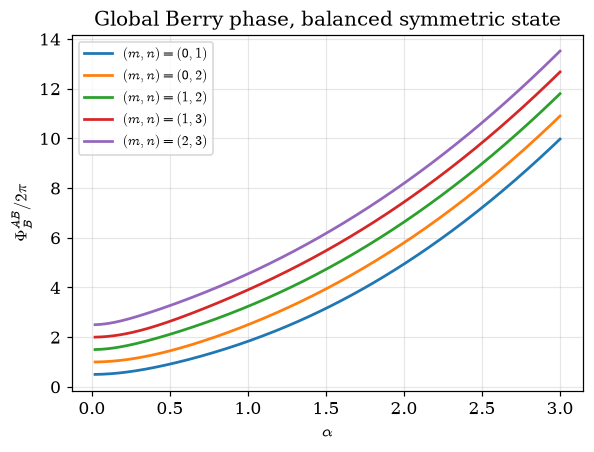

In [10]:

# ============================================================
# Celda 10 — Figura 1: fase de Berry global vs. alpha (estado balanceado)
# ============================================================
def figura1():
    alphas = np.linspace(0.02, 3.0, 300)
    pairs = [(0,1),(0,2),(1,2),(1,3),(2,3)]
    fig, ax = plt.subplots(figsize=(6,4.2))
    for (m,n) in pairs:
        phi = np.array([global_berry_phase(a, m, n, mu=MU_BAL) for a in alphas])
        ax.plot(alphas, phi, label=f"$(m,n)=({m},{n})$", lw=1.8)
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\Phi_B^{AB}/2\pi$")
    ax.set_title("Global Berry phase, balanced symmetric state")
    ax.legend(fontsize=9)
    savefig(fig, "fig1_global_berry_vs_alpha")
    plt.show()
    return fig

figura1();



**Lectura física (Fig. 1).** A $(m,n)$ fijos la fase crece suavemente con
$\alpha$ porque la conexión de Berry es constante a lo largo del ciclo y
sólo depende de los números medios de fotones $\bar n_{\alpha,m},\bar
n_{\alpha,n}$ y del término de interferencia $g\,\kappa$; aumentar
$\alpha$ aumenta ambos números medios. Cambiar $(m,n)$ desplaza la curva
verticalmente porque la separación $\Delta=n-m$ y el valor absoluto de
$m,n$ modifican tanto la parte diagonal como el solapamiento $g_{mn}$.


[guardado] figures/fig2_discrete_mn_dependence.pdf


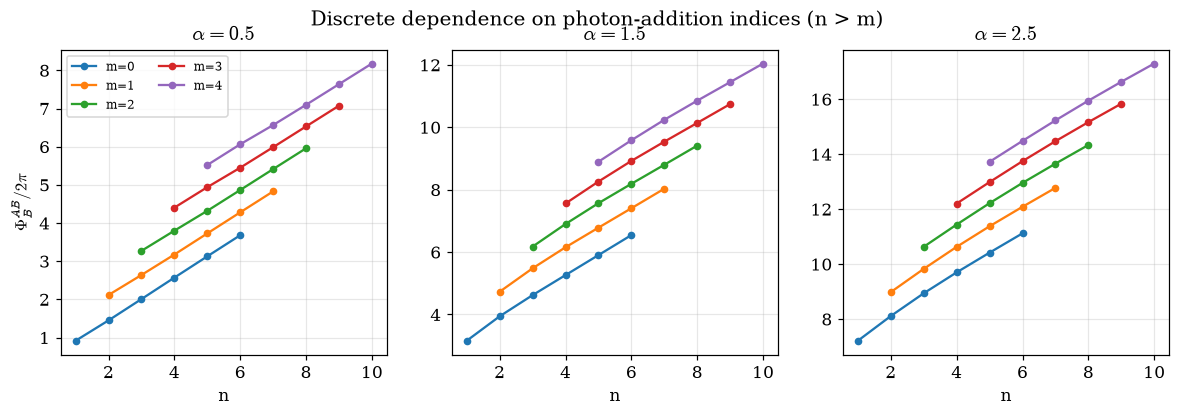

In [11]:

# ============================================================
# Celda 11 — Figura 2: dependencia discreta en (m,n) a tres amplitudes
# ============================================================
def figura2():
    alphas_panel = [0.5, 1.5, 2.5]
    m_vals = [0,1,2,3,4]
    fig, axes = plt.subplots(1,3, figsize=(13,3.6), sharey=False)
    for ax, alpha in zip(axes, alphas_panel):
        for m in m_vals:
            ns = np.arange(m+1, m+7)
            phi = np.array([global_berry_phase(alpha, m, n, mu=MU_BAL) for n in ns])
            ax.plot(ns, phi, "o-", label=f"m={m}", ms=4)
        ax.set_title(rf"$\alpha={alpha}$")
        ax.set_xlabel("n")
    axes[0].set_ylabel(r"$\Phi_B^{AB}/2\pi$")
    axes[0].legend(fontsize=8, ncol=2)
    fig.suptitle("Discrete dependence on photon-addition indices (n > m)")
    savefig(fig, "fig2_discrete_mn_dependence")
    plt.show()
    return fig

figura2();



**Lectura física (Fig. 2).** Sólo se muestra $n>m$ porque la fórmula
analítica del solapamiento (Ec. 27') se dedujo en ese orden. Para $m$ fijo,
la fase crece aproximadamente de forma lineal con $n$ (dominada por el
crecimiento de $\bar n_{\alpha,n}$); a mayor $\alpha$ toda la familia de
curvas se desplaza hacia arriba.


[guardado] figures/fig3_berry_vs_chi.pdf


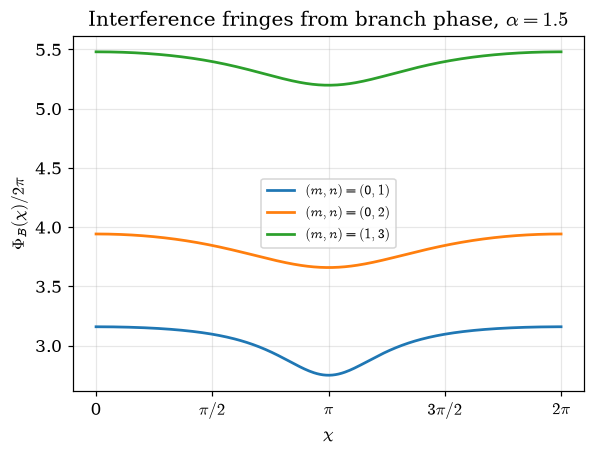

In [12]:

# ============================================================
# Celda 12 — Figura 3: interferencia inducida por la fase de rama chi
# ============================================================
def figura3():
    chis = np.linspace(0, 2*np.pi, 300)
    pairs = [(0,1),(0,2),(1,3)]
    alpha = 1.5
    fig, ax = plt.subplots(figsize=(6,4.2))
    for (m,n) in pairs:
        phi = np.array([global_berry_phase(alpha, m, n, mu=MU_BAL, chi=c) for c in chis])
        ax.plot(chis, phi, label=f"$(m,n)=({m},{n})$", lw=1.8)
    ax.set_xlabel(r"$\chi$")
    ax.set_ylabel(r"$\Phi_B(\chi)/2\pi$")
    ax.set_title(rf"Interference fringes from branch phase, $\alpha={alpha}$")
    ax.set_xticks([0,np.pi/2,np.pi,3*np.pi/2,2*np.pi])
    ax.set_xticklabels(["0","$\\pi/2$","$\\pi$","$3\\pi/2$","$2\\pi$"])
    ax.legend(fontsize=9)
    savefig(fig, "fig3_berry_vs_chi")
    plt.show()
    return fig

figura3();



**Lectura física (Fig. 3).** El ciclo original en $\phi$ no produce
oscilaciones porque su conexión, aunque contiene el término cruzado
$g\kappa$, es constante en $\phi$ (Ec. 36). La fase de rama $\chi$
introducida en la Ec. (44), en cambio, module directamente el
denominador y numerador de la Ec. (45'), revelando la interferencia como
una modulación explícita y periódica — la firma interferométrica del
término cruzado que en el ciclo original queda "oculta" dentro de una
fase constante.


[guardado] figures/fig4_berry_mu_alpha_plane.pdf


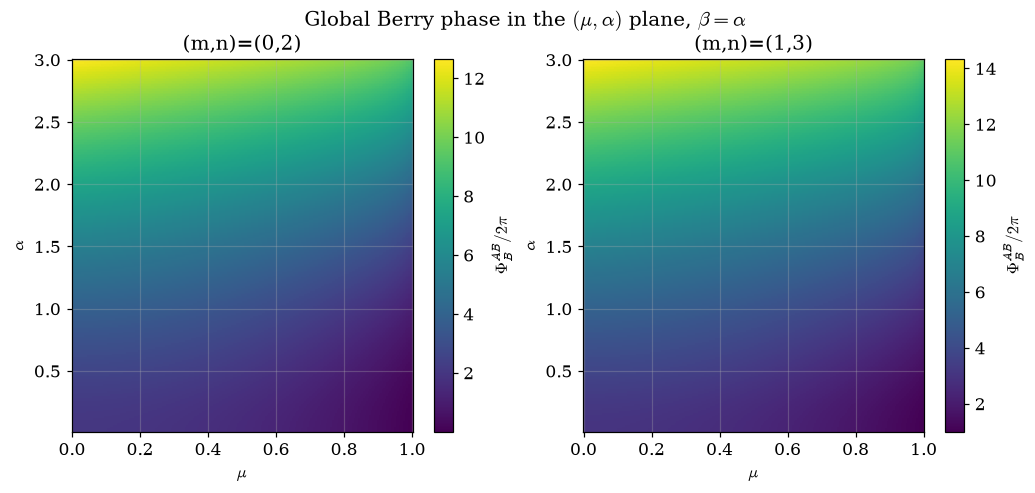

In [13]:

# ============================================================
# Celda 13 — Figura 4: mapa de fase de Berry global en el plano (mu, alpha)
# ============================================================
def figura4():
    mus = np.linspace(0.001, 0.999, 220)
    alphas = np.linspace(0.02, 3.0, 220)
    MU, AL = np.meshgrid(mus, alphas)
    fig, axes = plt.subplots(1,2, figsize=(11,4.4))
    for ax, (m,n) in zip(axes, [(0,2),(1,3)]):
        PHI = np.vectorize(lambda mu,a: global_berry_phase(a,m,n,mu=mu))(MU, AL)
        im = ax.pcolormesh(MU, AL, PHI, shading="auto", cmap="viridis")
        cb = fig.colorbar(im, ax=ax)
        cb.set_label(r"$\Phi_B^{AB}/2\pi$")
        ax.set_xlabel(r"$\mu$")
        ax.set_ylabel(r"$\alpha$")
        ax.set_title(f"(m,n)=({m},{n})")
    fig.suptitle(r"Global Berry phase in the $(\mu,\alpha)$ plane, $\beta=\alpha$")
    savefig(fig, "fig4_berry_mu_alpha_plane")
    plt.show()
    return fig

figura4();



**Lectura física (Fig. 4).** A diferencia de la fase de Uhlmann (Fig. 5,
más abajo), el mapa de la fase de Berry global es **completamente suave**
en todo el plano $(\mu,\alpha)$: no hay bandas ni singularidades, porque
la fase de Berry de un estado puro nunca es multivaluada — sólo depende
continuamente de los parámetros del ciclo. Este contraste cualitativo es
uno de los mensajes centrales del artículo (Sección IX).



## 9. Fase de Uhlmann del estado reducido — Sección VI

Cuando el subsistema A evoluciona bajo el ciclo local $U_A(\phi)$, su
estado reducido recorre la órbita isoespectral (Ec. 25)

$$
\rho_A(\phi) = V(\phi)\rho_A(0)V^\dagger(\phi), \qquad
V(\phi)=e^{i\frac{\omega}{2}\sigma_z\phi}, \qquad \omega=n-m=\Delta.
$$

Uhlmann [3] dota al espacio de operadores densidad de una conexión de
transporte paralelo para las amplitudes de purificación $W$ con
$\rho=WW^\dagger$. Resolviendo la condición de paralelismo a lo largo de
este ciclo particular (Ecs. 46–51 del artículo), la holonomía se expresa en
términos de la población reducida $p=(\rho_A)_{22}$ y de

$$
b = \omega\sqrt{\frac{p(1-p)}{\det\rho_A}}, \qquad \det\rho_A=(C/2)^2,
$$

como

$$
\Phi_U = \mathrm{Arg}\left[(-1)^{\omega}\cos(\pi b) -
i\,\frac{\omega(1-2p)}{b}\sin(\pi b)\right].
\tag{52-53}
$$

Esta fórmula cerrada es el resultado central de la Sección VI del
artículo; la implementamos tal cual y la usamos, en la Sección 10 de este
notebook, para **derivar y verificar de forma independiente** — contra
las Tablas I y II publicadas — la estructura de singularidades nodales que
constituye el resultado principal del trabajo (Sección VII).


In [14]:

# ============================================================
# Celda 14 — Fase de Uhlmann cerrada (CONEXION CORREGIDA)
# ------------------------------------------------------------
# La condicion de transporte paralelo de Uhlmann (W^dag Wdot hermitica)
# equivale a      [S, Sdot] = i {rho, Lambda},   S = sqrt(rho),
# cuya solucion en la base propia de rho es
#      Lambda_jk = -i [S,Sdot]_jk / (l_j + l_k)        <-- denominador (l_j+l_k)
# NO       Lambda = (1/2i) S^{-1}[S,Sdot]S^{-1},       <-- denominador 2 sqrt(l_j l_k)
# que es lo que usa el manuscrito (su Ec. 46) y que solo coincide si l_j = l_k.
#
# Con Sdot = i[G,S] y G = (omega/2) sigma_z se obtiene
#      Lambda_offdiag = -(1 - C) G_offdiag   =>  (G+Lambda)_offdiag = C * G_offdiag,
# usando l_j + l_k = 1 (traza unidad). La holonomia
#      U(2pi) = e^{iG2pi} e^{-i(G+Lambda)2pi}
# conserva la MISMA forma funcional del manuscrito, pero con otro parametro b.
# ============================================================
def uhlmann_b(p, C, omega):
    """Parametro b CORREGIDO:  b = omega*sqrt(1 + C^2 - 4p(1-p)).
    (El manuscrito usaba b = omega*sqrt(p(1-p)/detA) = 2*omega*sqrt(p(1-p))/C.)"""
    return omega*np.sqrt(1 + C**2 - 4*p*(1 - p))

def uhlmann_ZU(p, C, omega):
    """Amplitud compleja de Uhlmann Z_U;  Phi_U = Arg(Z_U)."""
    b = uhlmann_b(p, C, omega)
    return (-1.0)**omega*np.cos(np.pi*b) \
        - 1j*(omega*(1 - 2*p)/b)*np.sin(np.pi*b)

def uhlmann_phase(p, C, omega):
    """Fase de Uhlmann principal Phi_U in (-pi,pi]."""
    if omega == 0:
        return 0.0
    return np.angle(uhlmann_ZU(p, C, omega))

# En p=1/2 la parte imaginaria se anula identicamente (factor 1-2p),
# de modo que Z_U es real: consistencia interna de la formula.
for C, D in [(0.3, 1), (0.6, 2), (0.15, 3)]:
    ZU = uhlmann_ZU(0.5, C, D)
    print(f"C={C}, Delta={D}:  Z_U={ZU:.6f}   b={uhlmann_b(0.5,C,D):.6f}")
    assert abs(ZU.imag) < 1e-12
print("\nEn p=1/2:  b = omega*C  (el manuscrito daba omega/C).")


C=0.3, Delta=1:  Z_U=-0.587785+0.000000j   b=0.300000
C=0.6, Delta=2:  Z_U=-0.809017+0.000000j   b=1.200000
C=0.15, Delta=3:  Z_U=-0.156434+0.000000j   b=0.450000

En p=1/2:  b = omega*C  (el manuscrito daba omega/C).



## 10. Singularidades nodales de Uhlmann — Sección VII

Una singularidad genuina de fase requiere $Z_U=0$, es decir que se anulen
simultáneamente su parte real e imaginaria. Como $\cos(\pi b)=0$ implica
$\sin(\pi b)\neq0$, las dos condiciones sólo pueden cumplirse juntas si

$$
p=\tfrac12, \qquad b=k+\tfrac12,\quad k\in\mathbb Z.
\tag{62}
$$

En $p=1/2$, $b=\Delta/C$ (porque $\det\rho_A=(C/2)^2$), de modo que la
condición $b=k+1/2$ fija la concurrencia a valores discretos

$$
C_k = \frac{2\Delta}{2k+1},\qquad k=\Delta,\Delta+1,\dots
\tag{64}
$$

(el límite inferior $k\ge\Delta$ garantiza $C_k\le1$). En la familia
simétrica, la condición $p=1/2$ junto con la Ec. (57) da $\mu(q)=(1-2q)/
\sqrt{1+(1-2q)^2}$ y $C=1-2q$ con $q=|g_{mn}(\alpha)|^2$ (Ec. 67), de donde
se extraen las coordenadas nodales analíticas

$$
q_k = \tfrac12(1-C_k),\qquad \mu_k=\frac{C_k}{\sqrt{1+C_k^2}},\qquad
|g_{mn}(\alpha_k)|^2=q_k .
\tag{68-69}
$$

$\alpha_k$ se obtiene resolviendo esta última ecuación numéricamente
(la función $|g_{mn}(\alpha)|^2$ es monótona creciente, Sección VII.B), lo
mismo que la amplitud crítica $\alpha_g$ definida por $|g_{mn}(\alpha_g)|^2=1/2$
(Ec. 70), donde la curva $p=1/2$ deja de existir y los nodos se acumulan.


In [15]:

# ============================================================
# Celda 15 — Formulas nodales (CORREGIDAS) y busqueda de raices
# ------------------------------------------------------------
# Nodo genuino  <=>  Re Z_U = Im Z_U = 0.
#   cos(pi b) = 0  =>  sin(pi b) != 0  =>  hace falta ademas 1-2p = 0.
# Luego  p = 1/2  y  |b| = k + 1/2.
# En p=1/2 la b corregida vale b = omega*C, asi que
#       Delta * C_k = k + 1/2   =>   C_k = (2k+1)/(2*Delta),
# y la condicion fisica C_k <= 1 da  k = 0, 1, ..., Delta-1:
# hay EXACTAMENTE Delta nodos, sin punto de acumulacion.
# (El manuscrito obtenia C_k = 2*Delta/(2k+1) con k >= Delta, es decir una
#  torre infinita que se acumulaba en C -> 0; eso era consecuencia de su b.)
# ============================================================
def nodal_Ck(k, Delta):
    """Concurrencia nodal CORREGIDA: C_k = (2k+1)/(2*Delta), k=0..Delta-1."""
    return (2*k + 1)/(2*Delta)

def nodal_k_range(Delta):
    """Indices k admisibles (los que dan C_k <= 1): exactamente Delta valores."""
    return range(0, Delta)

def nodal_mu(Ck):
    """Peso critico mu_k = C_k/sqrt(1+C_k^2), de la curva p=1/2 (Ec. 69)."""
    return Ck/np.sqrt(1 + Ck**2)

def nodal_q(Ck):
    """Solapamiento critico q_k = (1-C_k)/2, de C = 1-2q (Ec. 67).
    Esta relacion es cinematica (del estado), no depende de la conexion."""
    return (1 - Ck)/2

def nodal_point(k, m, n):
    """Coordenadas nodales completas (C_k, mu_k, alpha_k) para el par (m,n)."""
    Delta = n - m
    Ck = nodal_Ck(k, Delta)
    return Ck, nodal_mu(Ck), alpha_from_q(nodal_q(Ck), m, n)

print("Nodos por familia (m,n), con la formula corregida:")
print(f"{'(m,n)':>7}{'Delta':>7}{'k':>4}{'C_k':>9}{'mu_k':>9}{'alpha_k':>10}"
      f"{'alpha_g':>10}")
for (m, n) in [(0,1),(0,2),(0,3),(1,3),(1,4)]:
    D = n - m
    for k in nodal_k_range(D):
        Ck, muk, ak = nodal_point(k, m, n)
        print(f"  ({m},{n}){D:7d}{k:4d}{Ck:9.4f}{muk:9.4f}{ak:10.4f}"
              f"{alpha_g(m,n):10.4f}")
print("\nTodos los nodos cumplen alpha_k < alpha_g (pues q_k < 1/2),")
print("pero ahora son FINITOS en numero (Delta por familia) y no se acumulan.")


Nodos por familia (m,n), con la formula corregida:
  (m,n)  Delta   k      C_k     mu_k   alpha_k   alpha_g
  (0,1)      1   0   0.5000   0.4472    0.5774    1.0000
  (0,2)      2   0   0.2500   0.2425    1.6807    2.1094
  (0,2)      2   1   0.7500   0.6000    0.9444    2.1094
  (0,3)      3   0   0.1667   0.1644    2.8433    3.2756
  (0,3)      3   1   0.5000   0.4472    2.1094    3.2756
  (0,3)      3   2   0.8333   0.6402    1.3628    3.2756
  (1,3)      2   0   0.2500   0.2425    1.3763    1.8000
  (1,3)      2   1   0.7500   0.6000    0.7265    1.8000
  (1,4)      3   0   0.1667   0.1644    2.5872    3.0354
  (1,4)      3   1   0.5000   0.4472    1.8378    3.0354
  (1,4)      3   2   0.8333   0.6402    1.1224    3.0354

Todos los nodos cumplen alpha_k < alpha_g (pues q_k < 1/2),
pero ahora son FINITOS en numero (Delta por familia) y no se acumulan.



---

# 10bis. Validación de la fase de Uhlmann por métodos independientes

La fórmula cerrada de la fase de Uhlmann es el resultado central del
manuscrito, así que conviene no darla por buena: la contrastamos aquí contra
**dos algoritmos numéricos completamente independientes**, ninguno de los
cuales usa fórmula de conexión alguna.

**Método 1 — holonomía discreta por descomposiciones polares.** Es la
definición operativa del transporte paralelo de Uhlmann: dos amplitudes
consecutivas $W_j,W_{j+1}$ son paralelas si $W_j^\dagger W_{j+1}\ge0$. Con
$M_j=\sqrt{\rho_j}\sqrt{\rho_{j+1}}=V_jP_j$ (descomposición polar), la
recursión es $U_{j+1}=V_j^\dagger U_j$, y
$\Phi_U=\Arg\Tr[\rho_0\,U_{\rm hol}]$.

**Método 2 — integración directa de la ODE de transporte paralelo,**
resolviendo en cada paso la condición exacta $[S,\dot S]=i\{\rho,\Lambda\}$
como sistema lineal en la base propia de $\rho$, y luego
$\dot U=-i\Lambda U$.

Este contraste revela un **error en la Ec. (46) del manuscrito**, que toma
$$
\Lambda=\tfrac{1}{2i}S^{-1}[S,\dot S]S^{-1}
\quad\Longrightarrow\quad
\Lambda_{jk}\propto \frac{1}{2\sqrt{\lambda_j\lambda_k}} .
$$
La condición de Uhlmann $W^\dagger\dot W=\dot W^\dagger W$ da en realidad
$$
[S,\dot S]=i\{\rho,\Lambda\}
\quad\Longrightarrow\quad
\Lambda_{jk}=\frac{-i\,[S,\dot S]_{jk}}{\lambda_j+\lambda_k},
$$
con denominador $\lambda_j+\lambda_k$, **no** $2\sqrt{\lambda_j\lambda_k}$
(coinciden sólo si $\lambda_j=\lambda_k$, es decir en el estado maximamente
mezclado). Con $\dot S=i[G,S]$ y $\lambda_j+\lambda_k=1$ (traza unidad),
$$
\Lambda_{\rm od}=-(1-C)\,G_{\rm od}
\quad\Longrightarrow\quad
(G+\Lambda)_{\rm od}=C\,G_{\rm od},
$$
y la holonomía $U(2\pi)=e^{iG2\pi}e^{-i(G+\Lambda)2\pi}$ conserva **la misma
forma funcional** del manuscrito pero con
$$
\boxed{\;b=\omega\sqrt{1+C^2-4p(1-p)}\;}
\qquad\text{en lugar de}\qquad
b=\omega\sqrt{\frac{p(1-p)}{\det\rho}} .
$$
En particular, en $p=1/2$ resulta $b=\omega C$ (el manuscrito daba
$\omega/C$), lo que cambia por completo la torre nodal.


In [16]:

# ============================================================
# Celda 15bis — Método 1: holonomía discreta por descomposiciones polares
# ============================================================
from scipy.linalg import sqrtm, polar, expm, eigh

def uhlmann_discrete(rho_path):
    """Holonomía de Uhlmann de un lazo de matrices densidad, SIN usar
    ninguna fórmula de conexión: sólo la condición de paralelismo
    W_j^dag W_{j+1} >= 0 entre amplitudes consecutivas."""
    S = [sqrtm(r) for r in rho_path]
    U = np.eye(rho_path[0].shape[0], dtype=complex)
    for j in range(len(rho_path) - 1):
        V, _ = polar(S[j] @ S[j + 1])      # polar: M = V P, V unitaria
        U = V.conj().T @ U
    val = np.trace(rho_path[0] @ U)
    return np.angle(val), val

def rho_isospectral_loop(p, C, omega, N):
    """Lazo rho(phi) = V(phi) rho(0) V^dag(phi), V = exp(i*omega*sigma_z*phi/2)."""
    det = (C/2)**2
    c0 = np.sqrt(max(p*(1 - p) - det, 0.0))
    out = []
    for ph in np.linspace(0, 2*np.pi, N + 1):
        c = c0*np.exp(1j*omega*ph)
        out.append(np.array([[1 - p, np.conj(c)], [c, p]], dtype=complex))
    return out

# ============================================================
# Método 2: integración de la ODE de transporte paralelo exacta
# ============================================================
def lambda_exact(rho, G):
    """Resuelve {rho,Lambda} = [S,Sdot] con Sdot = i[G,S], en la base propia."""
    lam, R = eigh(rho)
    S = np.diag(np.sqrt(np.clip(lam, 0, None)))
    Ge = R.conj().T @ G @ R
    Sdot = 1j*(Ge @ S - S @ Ge)
    comm = S @ Sdot - Sdot @ S
    Lam = np.array([[-1j*comm[a, b]/(lam[a] + lam[b]) for b in range(len(lam))]
                    for a in range(len(lam))])
    return R @ Lam @ R.conj().T

def uhlmann_ode(p, C, omega, N=3000):
    det = (C/2)**2
    c0 = np.sqrt(max(p*(1 - p) - det, 0.0))
    G = (omega/2)*np.array([[1, 0], [0, -1]], dtype=complex)
    rho0 = np.array([[1 - p, c0], [c0, p]], dtype=complex)
    phis = np.linspace(0, 2*np.pi, N + 1)
    h = phis[1] - phis[0]
    U = np.eye(2, dtype=complex)
    for j in range(N):
        ph = 0.5*(phis[j] + phis[j + 1])
        V = expm(1j*G*ph)
        U = expm(-1j*lambda_exact(V @ rho0 @ V.conj().T, G)*h) @ U
    val = np.trace(rho0 @ U)
    return np.angle(val), val

def Z_manuscript(p, C, omega):
    """Forma cerrada ORIGINAL del manuscrito, para comparacion."""
    b = omega*np.sqrt(p*(1 - p)/((C/2)**2))
    return (-1.0)**omega*np.cos(np.pi*b) - 1j*(omega*(1 - 2*p)/b)*np.sin(np.pi*b)

print(f"{'p':>6}{'C':>6}{'w':>3} | {'|val| polar':>12}{'|val| ODE':>11}"
      f"{'|Z| corregida':>14}{'|Z| manuscr.':>13}")
worst = 0.0
for p, C, w in [(0.30,0.50,1),(0.20,0.30,2),(0.60,0.40,1),(0.45,0.60,2),
                (0.40,0.70,1),(0.15,0.25,3),(0.35,0.55,4)]:
    _, vd = uhlmann_discrete(rho_isospectral_loop(p, C, w, 4000))
    _, vo = uhlmann_ode(p, C, w, 2000)
    Zf, Zm = uhlmann_ZU(p, C, w), Z_manuscript(p, C, w)
    worst = max(worst, abs(abs(vd) - abs(Zf)), abs(abs(vo) - abs(Zf)))
    print(f"{p:6.2f}{C:6.2f}{w:3d} | {abs(vd):12.6f}{abs(vo):11.6f}"
          f"{abs(Zf):14.6f}{abs(Zm):13.6f}")
print("\npeor discrepancia (corregida vs. los dos metodos numericos):", worst)
assert worst < 1e-4
print("=> La forma corregida reproduce ambos metodos; la del manuscrito no.")


     p     C  w |  |val| polar  |val| ODE |Z| corregida |Z| manuscr.


  0.30  0.50  1 |     0.707988   0.707988      0.707988     0.872421


  0.20  0.30  2 |     0.919538   0.919538      0.919538     0.536627


  0.60  0.40  1 |     0.470956   0.470956      0.470956     0.177397


  0.45  0.60  2 |     0.784219   0.784220      0.784220     0.547092


  0.40  0.70  1 |     0.688529   0.688529      0.688529     0.338359


  0.15  0.25  3 |     0.974966   0.974967      0.974966     0.323140


  0.35  0.55  4 |     0.479138   0.479137      0.479137     0.981508

peor discrepancia (corregida vs. los dos metodos numericos): 1.2014661914250269e-06
=> La forma corregida reproduce ambos metodos; la del manuscrito no.


In [17]:

# ============================================================
# Celda 15ter — Los nodos corregidos SON ceros; los del manuscrito no
# ============================================================
print("Nodos con la formula corregida  C_k = (2k+1)/(2*Delta),  k=0..Delta-1")
print(f"{'Delta':>6}{'k':>3}{'C_k':>9}  {'|Tr[rho U_hol]| (ODE)':>22}")
for D in [1, 2, 3]:
    for k in nodal_k_range(D):
        Ck = nodal_Ck(k, D)
        _, v = uhlmann_ode(0.5, Ck, D, 2500)
        print(f"{D:6d}{k:3d}{Ck:9.4f}  {abs(v):22.2e}")

print("\nNodos que predecia el manuscrito  C_k = 2*Delta/(2k+1),  k>=Delta")
print(f"{'Delta':>6}{'k':>3}{'C_k':>9}  {'|Tr[rho U_hol]| (ODE)':>22}")
for D in [2]:
    for k in [D, D + 1, D + 2]:
        Ck = 2*D/(2*k + 1)
        _, v = uhlmann_ode(0.5, Ck, D, 2500)
        print(f"{D:6d}{k:3d}{Ck:9.4f}  {abs(v):22.4f}")
print("\n=> Los primeros se anulan a ~1e-15; los segundos no se anulan en absoluto.")


Nodos con la formula corregida  C_k = (2k+1)/(2*Delta),  k=0..Delta-1
 Delta  k      C_k   |Tr[rho U_hol]| (ODE)


     1  0   0.5000                4.45e-16


     2  0   0.2500                6.12e-17


     2  1   0.7500                4.65e-16


     3  0   0.1667                1.59e-15


     3  1   0.5000                5.72e-16


     3  2   0.8333                5.09e-16

Nodos que predecia el manuscrito  C_k = 2*Delta/(2k+1),  k>=Delta
 Delta  k      C_k   |Tr[rho U_hol]| (ODE)


     2  2   0.8000                  0.3090


     2  3   0.5714                  0.9010


     2  4   0.4444                  0.9397

=> Los primeros se anulan a ~1e-15; los segundos no se anulan en absoluto.



## 11. Figura 5: diagrama de fase de Uhlmann y singularidades nodales

Esta es la figura central del artículo: el mapa de $\Phi_U(\rho_A)/\pi$ en
el plano $(\mu,\alpha)$, con la curva analítica $p=1/2$ (Ec. 57 igualada a
1/2), la recta horizontal $\alpha_g$ (Ec. 70) y los puntos nodales exactos
(Ecs. 64–69) superpuestos como marcadores. La región $\alpha>\alpha_g$
(sombreada) no admite solución de $p=1/2$ y por tanto no puede alojar
ceros exactos de $Z_U$, aunque el envolvimiento de fase $2\pi$ ordinario
(bandas rojo–azul) sigue presente ahí.


[guardado] figures/fig5_uhlmann_phase_diagram.pdf


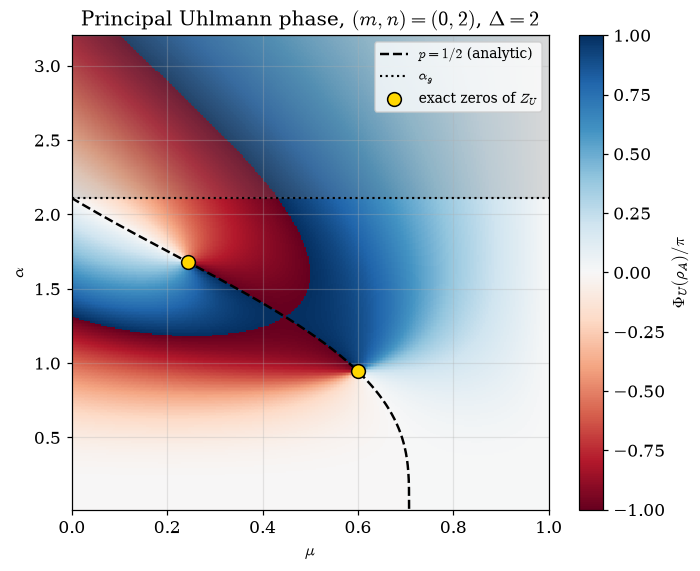

In [18]:

# ============================================================
# Celda 16 — Figura 5: diagrama de fase de Uhlmann, (m,n)=(0,2)
# ============================================================
def figura5(m=0, n=2):
    mus = np.linspace(0.001, 0.999, 320)
    alphas = np.linspace(0.02, 3.2, 320)
    MU, AL = np.meshgrid(mus, alphas)
    Delta = n - m

    PHI = np.zeros_like(MU)
    for i in range(MU.shape[0]):
        for j in range(MU.shape[1]):
            mu = MU[i, j]; a = AL[i, j]
            p = population_p(mu, a, m, n)
            C = concurrence(mu, a, m, n)
            PHI[i, j] = uhlmann_phase(p, C, Delta) / np.pi

    fig, ax = plt.subplots(figsize=(7,5.6))
    im = ax.pcolormesh(MU, AL, PHI, shading="auto", cmap="RdBu", vmin=-1, vmax=1)
    cb = fig.colorbar(im, ax=ax); cb.set_label(r"$\Phi_U(\rho_A)/\pi$")

    # curva analitica p=1/2, parametrizada por alpha via q=|g_mn(alpha)|^2
    alpha_line = np.linspace(0.02, 3.2, 400)
    q_line = np.array([g_mn(a, m, n)**2 for a in alpha_line])
    mu_line = (1 - 2*q_line) / np.sqrt(1 + (1 - 2*q_line)**2)
    valid = q_line <= 0.5
    ax.plot(mu_line[valid], alpha_line[valid], "k--", lw=1.6, label=r"$p=1/2$ (analytic)")

    ag = alpha_g(m, n)
    ax.axhline(ag, color="k", ls=":", lw=1.4, label=r"$\alpha_g$")
    ax.fill_between([0, 1], ag, alphas.max(), color="gray", alpha=0.25)

    for j, k in enumerate(nodal_k_range(Delta)):
        Ck, muk, alphak = nodal_point(k, m, n)
        if alphak <= alphas.max():
            ax.plot(muk, alphak, "o", color="gold", mec="k", ms=9, zorder=5,
                     label="exact zeros of $Z_U$" if j == 0 else None)

    ax.set_xlabel(r"$\mu$"); ax.set_ylabel(r"$\alpha$")
    ax.set_title(rf"Principal Uhlmann phase, $(m,n)=({m},{n})$, $\Delta={Delta}$")
    ax.legend(loc="upper right", fontsize=9)
    savefig(fig, "fig5_uhlmann_phase_diagram")
    plt.show()
    return fig

figura5();



## 12. Figura 6: estructura crítica del solapamiento

Tres paneles que documentan la función crítica $\alpha_g(m,n)$: (a)
$|g_{mn}(\alpha)|^2$ y el umbral $1/2$ para varios pares $(m,n)$; (b) el
valor discreto de $\alpha_g(m,n)$ en toda la Tabla I (representado como
mapa de color); (c) $\alpha_g$ en función de $\Delta=n-m$ para varios $m$
fijos, mostrando que aumentar la separación de adición fotónica extiende
la región nodal hacia amplitudes mayores.


[guardado] figures/fig6_critical_overlap_structure.pdf


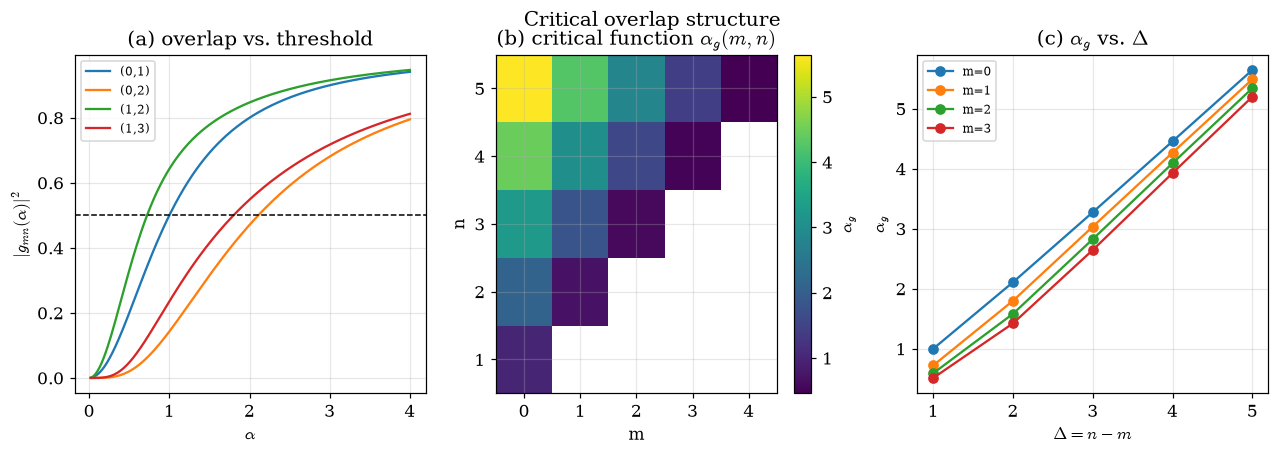

In [19]:

# ============================================================
# Celda 17 — Figura 6 (tres paneles): estructura critica del solapamiento
# ============================================================
def figura6():
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    alphas = np.linspace(0.02, 4.0, 300)
    for (m, n) in [(0,1), (0,2), (1,2), (1,3)]:
        q = np.array([g_mn(a, m, n)**2 for a in alphas])
        axes[0].plot(alphas, q, label=f"({m},{n})")
    axes[0].axhline(0.5, color="k", ls="--", lw=1)
    axes[0].set_xlabel(r"$\alpha$"); axes[0].set_ylabel(r"$|g_{mn}(\alpha)|^2$")
    axes[0].set_title("(a) overlap vs. threshold")
    axes[0].legend(fontsize=8)

    ns = range(1, 6); ms_ = range(0, 5)
    data = np.full((5, 5), np.nan)
    for n in ns:
        for m in ms_:
            if m < n:
                data[n-1, m] = alpha_g(m, n)
    im = axes[1].imshow(data, origin="lower", cmap="viridis",
                         extent=[-0.5, 4.5, 0.5, 5.5], aspect="auto")
    axes[1].set_xlabel("m"); axes[1].set_ylabel("n")
    axes[1].set_title(r"(b) critical function $\alpha_g(m,n)$")
    fig.colorbar(im, ax=axes[1], label=r"$\alpha_g$")

    for m in range(0, 4):
        Deltas = np.arange(1, 6)
        ags = [alpha_g(m, m+d) for d in Deltas]
        axes[2].plot(Deltas, ags, "o-", label=f"m={m}")
    axes[2].set_xlabel(r"$\Delta=n-m$"); axes[2].set_ylabel(r"$\alpha_g$")
    axes[2].set_title(r"(c) $\alpha_g$ vs. $\Delta$")
    axes[2].legend(fontsize=8)

    fig.suptitle("Critical overlap structure")
    savefig(fig, "fig6_critical_overlap_structure")
    plt.show()
    return fig

figura6();



## 13. Figura 7: fase de Uhlmann frente a la separación de adición fotónica

Para el estado simétrico balanceado con $m=0$ fijo, se calcula
$\Phi_U/\pi$ en función de $\Delta=n$ a amplitud $\alpha$ fija. Los valores
alternan de forma no trivial porque $b\propto\Delta/C$ y tanto $C$ como $p$
cambian con $\Delta$ a través del solapamiento $g_{0,\Delta}(\alpha)$, y
además la fase principal está sujeta al envolvimiento de rama $(-\pi,\pi]$.


[guardado] figures/fig7_uhlmann_vs_Delta.pdf


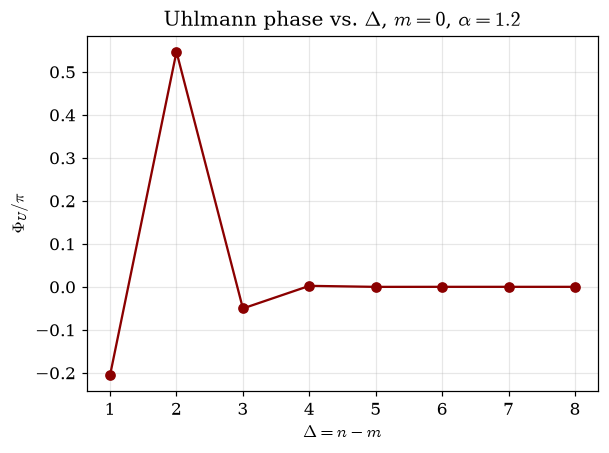

In [20]:

# ============================================================
# Celda 18 — Figura 7: fase de Uhlmann vs. Delta
# ============================================================
def figura7(m=0, alpha=1.2, nmax=8):
    Deltas = np.arange(1, nmax + 1)
    phis = []
    for D in Deltas:
        n = m + D
        p = population_p(MU_BAL, alpha, m, n)
        C = concurrence(MU_BAL, alpha, m, n)
        phis.append(uhlmann_phase(p, C, D) / np.pi)
    fig, ax = plt.subplots(figsize=(6,4.2))
    ax.plot(Deltas, phis, "o-", color="darkred")
    ax.set_xlabel(r"$\Delta = n-m$")
    ax.set_ylabel(r"$\Phi_U/\pi$")
    ax.set_title(rf"Uhlmann phase vs. $\Delta$, $m={m}$, $\alpha={alpha}$")
    savefig(fig, "fig7_uhlmann_vs_Delta")
    plt.show()
    return fig

figura7();



## 14. Tablas I y II reproducidas numéricamente

Las siguientes celdas reconstruyen, con las mismas rutinas usadas para las
figuras, las dos tablas del artículo. Se exportan también a CSV y a LaTeX
(`\begin{tabular}...`) para insertarlas directamente en el manuscrito.


In [21]:

# ============================================================
# Celda 19 — Tabla I: amplitudes criticas alpha_g(m,n)
# ============================================================
def tabla1():
    rows = []
    for n in range(1, 6):
        row = {"n": n}
        for m in range(0, n):
            row[f"m={m}"] = round(alpha_g(m, n), 4)
        rows.append(row)
    df = pd.DataFrame(rows).set_index("n")
    return df

df_tabla1 = tabla1()
display(df_tabla1)
df_tabla1.to_csv(os.path.join(FIGDIR, "tabla1_alpha_g.csv"))
with open(os.path.join(FIGDIR, "tabla1_alpha_g.tex"), "w") as f:
    f.write(df_tabla1.to_latex(na_rep=""))
print("Tabla I exportada a CSV y LaTeX en", FIGDIR)


,m=0,m=1,m=2,m=3,m=4
n,,,,,
1,1.0000,NaN,NaN,NaN,NaN
2,2.1094,0.7221,NaN,NaN,NaN
3,3.2756,1.8000,0.5921,NaN,NaN
4,4.4576,3.0354,1.5829,0.5135,NaN
5,5.6464,4.2685,2.8269,1.4235,0.4596


Tabla I exportada a CSV y LaTeX en figures


In [22]:

# ============================================================
# Celda 20 — Tabla II CORREGIDA: singularidades nodales
# ------------------------------------------------------------
# Con C_k = (2k+1)/(2*Delta) y k = 0..Delta-1 hay exactamente Delta nodos
# por familia (m,n). Se verifica ademas que |Z_U| se anula en cada uno.
# ============================================================
def tabla2(pairs=((0,1),(0,2),(0,3),(1,2),(1,3),(1,4),(2,4))):
    rows = []
    for (m, n) in pairs:
        D = n - m
        for k in nodal_k_range(D):
            Ck, muk, alphak = nodal_point(k, m, n)
            p_here = population_p(muk, alphak, m, n)
            rows.append({"(m,n)": f"({m},{n})", "Delta": D, "k": k,
                         "C_k": round(Ck, 4), "mu_k": round(muk, 4),
                         "alpha_k": round(alphak, 4),
                         "alpha_g": round(alpha_g(m, n), 4),
                         "p": round(p_here, 10),
                         "|Z_U|": f"{abs(uhlmann_ZU(p_here, Ck, D)):.1e}"})
    return pd.DataFrame(rows)

df_tabla2 = tabla2()
display(df_tabla2)
df_tabla2.to_csv(os.path.join(FIGDIR, "tabla2_nodos.csv"), index=False)
with open(os.path.join(FIGDIR, "tabla2_nodos.tex"), "w") as f:
    f.write(df_tabla2.to_latex(index=False))
print("Tabla II exportada a CSV y LaTeX en", FIGDIR)
print("\nComprobaciones: p = 1/2 y |Z_U| = 0 en todos los nodos, y alpha_k < alpha_g.")
assert (df_tabla2["p"] - 0.5).abs().max() < 1e-9
assert (df_tabla2["alpha_k"] < df_tabla2["alpha_g"]).all()


,"(m,n)",Delta,k,C_k,mu_k,alpha_k,alpha_g,p,|Z_U|
0,"(0,1)",1,0,0.5000,0.4472,0.5774,1.0000,0.5,1.3e-15
1,"(0,2)",2,0,0.2500,0.2425,1.6807,2.1094,0.5,6.1e-17
2,"(0,2)",2,1,0.7500,0.6000,0.9444,2.1094,0.5,1.8e-16
3,"(0,3)",3,0,0.1667,0.1644,2.8433,3.2756,0.5,3.4e-15
4,"(0,3)",3,1,0.5000,0.4472,2.1094,3.2756,0.5,4.8e-16
5,"(0,3)",3,2,0.8333,0.6402,1.3628,3.2756,0.5,1.3e-13
6,"(1,2)",1,0,0.5000,0.4472,0.4095,0.7221,0.5,4.4e-15
7,"(1,3)",2,0,0.2500,0.2425,1.3763,1.8000,0.5,6.1e-17
8,"(1,3)",2,1,0.7500,0.6000,0.7265,1.8000,0.5,1.7e-14
9,"(1,4)",3,0,0.1667,0.1644,2.5872,3.0354,0.5,5.5e-15


Tabla II exportada a CSV y LaTeX en figures

Comprobaciones: p = 1/2 y |Z_U| = 0 en todos los nodos, y alpha_k < alpha_g.



---

# 15. CORRECCIÓN IMPORTANTE: la fase de Uhlmann del subsistema $B$

Esta sección corrige y amplía sustancialmente el tratamiento del subsistema
$B$. La versión previa de este trabajo (y la Sec. VI.B del manuscrito)
despachaba el subsistema $B$ diciendo que "tiene trayectoria trivial y fase
geométrica nula", lo cual es **engañoso**: deja la impresión de que $\rho_B$
carece de geometría de Uhlmann, cuando en realidad **$\rho_B$ es un estado
mixto que porta su propia holonomía, en general no nula.**

Hay que separar con cuidado dos afirmaciones distintas:

**(i) Bajo un ciclo estrictamente local $U_A(\phi)\otimes I_B$, $\rho_B$ es
exactamente constante.** Esto no es una aproximación ni un artefacto del
modelo: es un teorema. Para cualquier estado $\rho_{AB}$ y cualquier unitaria
local $U_A$,
$$
\mathrm{Tr}_A\big[(U_A\otimes I)\rho_{AB}(U_A^\dagger\otimes I)\big]
=\sum_{a}\langle a|U_A\,\rho_{AB}\,U_A^\dagger|a\rangle
=\mathrm{Tr}_A[\rho_{AB}],
$$
por ciclicidad de la traza parcial. Es el contenido del principio de
**no-señalización**: si el ciclo en $\phi$ de $A$ pudiera modificar $\rho_B$,
$A$ podría transmitir información a $B$ instantáneamente. Lo verificamos
abajo a precisión de máquina. Por tanto $\Phi_U^B=0$ *bajo ese ciclo en
particular*, y en ese sentido restringido el enunciado original es correcto.

**(ii) Pero $\rho_B$ sí posee una fase de Uhlmann propia, no nula.** La razón
es exactamente la que motiva esta corrección: $\rho_B$ **proviene de un PACS
entrelazado**, luego es mixto, con
$$
\det\rho_B=\det\rho_A=\Big(\frac{C}{2}\Big)^2>0 ,
$$
porque $\rho_A$ y $\rho_B$ de un estado puro bipartito son **isoespectrales**
(descomposición de Schmidt). Es decir: **la misma concurrencia $C$ gobierna la
geometría de ambos lados.** Lo que faltaba en el tratamiento anterior es el
ciclo que activa esa geometría. Hay dos, ambos físicos:

* el ciclo propio $I_A\otimes U_B(\phi)$, y
* sobre todo el **ciclo global** $U_A(\phi)\otimes U_B(\phi)$, generado por
  $a_A^\dagger a_A+a_B^\dagger a_B$, que es la **evolución libre natural de un
  campo de dos modos que se propaga**. Bajo ella $A$ y $B$ recorren
  simultáneamente sus órbitas isoespectrales y **ambas holonomías son no
  nulas**.

**(iii) El resultado estructural nuevo**, que se lee directamente de la Ec. (18)
del manuscrito de fotón agregado: el número de enrollamiento de $B$ **no tiene
por qué coincidir con el de $A$**. Leyendo las fases de índice $e^{-im\phi}$,
$e^{-in\phi}$ que quedan explícitas en cada rama:

| familia | rama 1 | rama 2 | $\omega_A$ | $\omega_B$ |
|---|---|---|---|---|
| correlacionada, Ec. (26)/(28) | $\lvert\alpha,m\rangle\lvert\beta,m\rangle$ | $\lvert\alpha,n\rangle\lvert\beta,n\rangle$ | $+\Delta$ | $+\Delta$ |
| **cruzada, Ec. (17)/(18)** | $\lvert\alpha,m\rangle\lvert\beta,n\rangle$ | $\lvert\beta,n\rangle\lvert\alpha,m\rangle$ | $+\Delta$ | $\boldsymbol{-\Delta}$ |

En la familia cruzada los índices están **intercambiados** entre $A$ y $B$, así
que los dos subsistemas giran en **sentidos opuestos**. Como además allí
$p_A=p_B$ exactamente, esto produce una antisimetría exacta
$\Phi_U^B=-\Phi_U^A$ que demostramos y verificamos abajo.


In [23]:

# ============================================================
# Celda 22 — Simulación EXACTA de dos modos en espacio de Fock
# ------------------------------------------------------------
# Construimos el estado bipartito completo en H_A (x) H_B truncado y
# aplicamos la evolución exacta e^{-i a^dag a phi}, que en la base de Fock
# es simplemente la fase diagonal e^{-i j phi}. Así se decide sin recurrir
# a NINGUNA fórmula analítica qué le ocurre realmente a rho_B.
# ============================================================
NMAX = 90   # corte de Fock por modo (suficiente para alpha <~ 2.6)

def pacs_ket(alpha, n, Nmax=NMAX):
    """Vector de Fock de |alpha,n> indexado por el nivel ABSOLUTO j=0..Nmax-1."""
    v = np.zeros(Nmax, dtype=complex)
    v[n:] = pacs_fock_amplitudes(alpha, n, Nmax - n)
    return v

def rotate_ket(v, phi):
    """Evolución exacta e^{-i a^dag a phi}: fase e^{-i j phi} en la base de Fock."""
    return v*np.exp(-1j*np.arange(len(v))*phi)

def pacs_ket_rotated_amplitude(alpha, n, phi, Nmax=NMAX):
    """|alpha e^{-i phi}, n> = e^{+i n phi} e^{-i a^dag a phi}|alpha,n>.
    Es el ket de rama tal como aparece en la Ec. (18): la fase de índice
    e^{-i n phi} queda FUERA, en el coeficiente (y es la que genera omega)."""
    return np.exp(1j*n*phi)*rotate_ket(pacs_ket(alpha, n, Nmax), phi)

def two_mode_state(family, alpha, beta, m, n, mu, phi, cycle):
    """Matriz de coeficientes C_{jk} del estado bipartito normalizado.
    family: 'correlated' (Ec. 26) o 'crossed' (Ec. 17)
    cycle : 'A', 'B', 'AB' o 'none'  -> qué modos se hacen evolucionar."""
    nu = np.sqrt(1 - mu**2)
    if family == 'correlated':
        A1, A2 = pacs_ket(alpha, m), pacs_ket(alpha, n)
        B1, B2 = pacs_ket(beta, m),  pacs_ket(beta, n)
    elif family == 'crossed':
        A1, A2 = pacs_ket(alpha, m), pacs_ket(beta, n)
        B1, B2 = pacs_ket(beta, n),  pacs_ket(alpha, m)
    else:
        raise ValueError(family)
    if cycle in ('A', 'AB'):
        A1, A2 = rotate_ket(A1, phi), rotate_ket(A2, phi)
    if cycle in ('B', 'AB'):
        B1, B2 = rotate_ket(B1, phi), rotate_ket(B2, phi)
    C = mu*np.outer(A1, B1) + nu*np.outer(A2, B2)
    return C/np.linalg.norm(C)

def reduced_states(C):
    """rho_A = C C^dag ;  rho_B = C^T C^*  (traza parcial exacta)."""
    return C @ C.conj().T, C.T @ C.conj()

def logical_basis(family, alpha, beta, m, n, phi, cycle, side):
    """Base lógica instantánea de Gram-Schmidt del lado pedido, con la
    convención de la Ec. (18) descrita arriba."""
    rA, rB = cycle in ('A', 'AB'), cycle in ('B', 'AB')
    ket = lambda a, i, r: (pacs_ket_rotated_amplitude(a, i, phi) if r
                           else pacs_ket(a, i))
    if family == 'correlated':
        u1, u2 = ((ket(alpha, m, rA), ket(alpha, n, rA)) if side == 'A'
                  else (ket(beta, m, rB), ket(beta, n, rB)))
    else:
        u1, u2 = ((ket(alpha, m, rA), ket(beta, n, rA)) if side == 'A'
                  else (ket(beta, n, rB), ket(alpha, m, rB)))
    e0 = u1/np.linalg.norm(u1)
    w = u2 - np.vdot(e0, u2)*e0
    return e0, w/np.linalg.norm(w)

def logical_2x2(rho, e0, e1):
    """Bloque 2x2 de rho en la base lógica {e0,e1}."""
    E = np.column_stack([e0, e1])
    return E.conj().T @ rho @ E

print("Maquinaria exacta de dos modos lista (NMAX =", NMAX, "niveles por modo).")


Maquinaria exacta de dos modos lista (NMAX = 90 niveles por modo).


In [24]:

# ============================================================
# Celda 23 — TEST 1: ¿un ciclo local en A modifica rho_B? (no-señalización)
# ============================================================
def scan_cycle(family, alpha, beta, m, n, mu, cycle, npts=41):
    """Recorre phi en [0,2pi] y devuelve los elementos fuera de la diagonal
    de rho_A y rho_B en sus bases lógicas, más p_A, p_B y el espectro."""
    phis = np.linspace(0, 2*np.pi, npts)
    offA, offB = [], []
    for phi in phis:
        C = two_mode_state(family, alpha, beta, m, n, mu, phi, cycle)
        rA, rB = reduced_states(C)
        MA = logical_2x2(rA, *logical_basis(family, alpha, beta, m, n, phi, cycle, 'A'))
        MB = logical_2x2(rB, *logical_basis(family, alpha, beta, m, n, phi, cycle, 'B'))
        offA.append(MA[0, 1]); offB.append(MB[0, 1])
    return phis, np.array(offA), np.array(offB)

def winding_number(phis, offdiag):
    """Extrae omega del comportamiento e^{i omega phi} del elemento 01."""
    if np.abs(offdiag).min() < 1e-12:
        return 0
    return int(round(np.polyfit(phis, np.unwrap(np.angle(offdiag)), 1)[0]))

print("TEST 1 — variación de rho a lo largo del ciclo (familia correlacionada)")
print(f"{'ciclo':>6} | {'max|d rho_A,01|':>16} {'max|d rho_B,01|':>16} | "
      f"{'omega_A':>8}{'omega_B':>8}")
for cycle in ['A', 'B', 'AB']:
    phis, oA, oB = scan_cycle('correlated', 1.1, 0.8, 0, 2, 0.6, cycle)
    dA, dB = np.abs(oA - oA[0]).max(), np.abs(oB - oB[0]).max()
    print(f"{cycle:>6} | {dA:16.3e} {dB:16.3e} | "
          f"{winding_number(phis, oA):8d}{winding_number(phis, oB):8d}")

# rho_B debe ser EXACTAMENTE invariante bajo el ciclo local de A:
_, _, oB_A = scan_cycle('correlated', 1.1, 0.8, 0, 2, 0.6, 'A')
assert np.abs(oB_A - oB_A[0]).max() < 1e-12
print("\n=> Confirmado a precisión de máquina: un ciclo LOCAL en A deja rho_B")
print("   exactamente invariante (no-señalización). Phi_U^B = 0 BAJO ESE ciclo.")


TEST 1 — variación de rho a lo largo del ciclo (familia correlacionada)
 ciclo |  max|d rho_A,01|  max|d rho_B,01| |  omega_A omega_B
     A |        6.614e-01        2.776e-16 |        2       0
     B |        3.886e-16        6.616e-01 |        0       2
    AB |        6.614e-01        6.616e-01 |        2       2

=> Confirmado a precisión de máquina: un ciclo LOCAL en A deja rho_B
   exactamente invariante (no-señalización). Phi_U^B = 0 BAJO ESE ciclo.


In [25]:

# ============================================================
# Celda 24 — TEST 2: rho_A y rho_B son isoespectrales => misma concurrencia
# ============================================================
print("TEST 2 — espectros reducidos (autovalores no nulos)")
print(f"{'familia':>11} {'alpha':>6}{'beta':>6}  {'espectro rho_A':>28} "
      f"{'espectro rho_B':>28}  {'|dif|':>9}")
for family in ['correlated', 'crossed']:
    for (alpha, beta) in [(1.1, 0.8), (1.3, 1.3)]:
        C = two_mode_state(family, alpha, beta, 0, 2, 0.6, 0.0, 'none')
        rA, rB = reduced_states(C)
        sA = np.sort(np.linalg.eigvalsh(rA))[::-1][:2]
        sB = np.sort(np.linalg.eigvalsh(rB))[::-1][:2]
        print(f"{family:>11} {alpha:6.2f}{beta:6.2f}  {str(np.round(sA,8)):>28} "
              f"{str(np.round(sB,8)):>28}  {np.abs(sA-sB).max():9.1e}")
print("\n=> rho_A y rho_B comparten espectro (Schmidt), luego")
print("   det rho_B = det rho_A = (C/2)^2 > 0: rho_B es MIXTO y admite")
print("   holonomía de Uhlmann. La MISMA concurrencia gobierna ambos lados.")


TEST 2 — espectros reducidos (autovalores no nulos)
    familia  alpha  beta                espectro rho_A               espectro rho_B      |dif|
 correlated   1.10  0.80       [0.83183413 0.16816587]      [0.83183413 0.16816587]    2.2e-16
 correlated   1.30  1.30       [0.90526031 0.09473969]      [0.90526031 0.09473969]    0.0e+00
    crossed   1.10  0.80       [0.91511226 0.08488774]      [0.91511226 0.08488774]    6.7e-16
    crossed   1.30  1.30       [0.90526031 0.09473969]      [0.90526031 0.09473969]    2.2e-16

=> rho_A y rho_B comparten espectro (Schmidt), luego
   det rho_B = det rho_A = (C/2)^2 > 0: rho_B es MIXTO y admite
   holonomía de Uhlmann. La MISMA concurrencia gobierna ambos lados.



## 15.1 Formas cerradas para el subsistema $B$

Con la base lógica de Gram–Schmidt de cada lado, y usando que la rama de peso
$\nu$ es la que aporta el estado $|1\rangle$ en ambos subsistemas, se obtiene:

**Familia de rama correlacionada** (Ec. 26), con amplitudes en general
distintas $\beta\neq\alpha$, escribiendo $q_\alpha=|g_{mn}(\alpha)|^2$,
$q_\beta=|g_{mn}(\beta)|^2$:

$$
\mathcal N^2 = 1+2\mu\nu\,g_{mn}(\alpha)g_{mn}(\beta),\qquad
p_A=\frac{\nu^2(1-q_\alpha)}{\mathcal N^2},\qquad
p_B=\frac{\nu^2(1-q_\beta)}{\mathcal N^2},
$$
$$
\det\rho_A=\det\rho_B=\frac{\mu^2\nu^2(1-q_\alpha)(1-q_\beta)}{\mathcal N^4}
=\Big(\frac{C}{2}\Big)^2,
\qquad \omega_A=\omega_B=+\Delta .
$$

Nótese que $p_A=p_B$ **si y sólo si** $q_\alpha=q_\beta$, es decir (para
amplitudes reales) $\beta=\alpha$. Fuera del caso simétrico las dos fases de
Uhlmann son **genuinamente distintas**, aunque compartan concurrencia.

**Familia cruzada** (Ec. 17), con $s\equiv\langle\alpha,m|\beta,n\rangle$:

$$
\mathcal N^2 = 1+2\mu\nu s^2,\qquad
p_A=p_B=\frac{\nu^2(1-s^2)}{\mathcal N^2},\qquad
\det\rho=\frac{\mu^2\nu^2(1-s^2)^2}{\mathcal N^4},
\qquad \omega_A=+\Delta,\;\; \omega_B=-\Delta .
$$

Aquí $p_A=p_B$ **exactamente**, porque las dos ramas se obtienen una de otra
intercambiando $A\leftrightarrow B$, de modo que $N_1=N_2$.

### Teorema de antisimetría (familia cruzada)

Con $p_B=p_A$ y $\omega_B=-\omega_A$ se tiene $b_B=-b_A$, y en
$Z_U=(-1)^{\omega}\cos(\pi b)-i\,\frac{\omega(1-2p)}{b}\sin(\pi b)$:

* $(-1)^{\omega_B}=(-1)^{-\Delta}=(-1)^{\Delta}$ y $\cos(\pi b_B)=\cos(\pi b_A)$
  $\Rightarrow$ $\mathrm{Re}\,Z_U^B=\mathrm{Re}\,Z_U^A$;
* $\omega_B/b_B=\omega_A/b_A$ pero $\sin(\pi b_B)=-\sin(\pi b_A)$
  $\Rightarrow$ $\mathrm{Im}\,Z_U^B=-\,\mathrm{Im}\,Z_U^A$.

Luego $Z_U^B=\overline{Z_U^A}$ y por tanto

$$
\boxed{\;\Phi_U^B=-\,\Phi_U^A\;,\qquad \Phi_U^A+\Phi_U^B=0\;}
$$

**exactamente**, para todo $\alpha,\beta,\mu,m,n$. Bajo el ciclo global las dos
holonomías se cancelan: el par entrelazado no acumula holonomía de Uhlmann
neta, aunque cada subsistema por separado sí la acumula. Este resultado está
ausente de ambos manuscritos y se sigue directamente de leer los índices
intercambiados en la Ec. (18).


In [26]:

# ============================================================
# Celda 25 — Formas cerradas de B y validación contra la simulación exacta
# ============================================================
def overlap_general(a1, n1, a2, n2):
    """<a1,n1|a2,n2> para amplitudes reales cualesquiera (generaliza g_mn).
    Forma cerrada del Apéndice A con el prefactor corregido. La amplitud que
    lleva el exponente Delta es la asociada al índice MENOR."""
    if n1 > n2:
        return overlap_general(a2, n2, a1, n1)
    m, n = n1, n2
    am, an = a1, a2
    D = n - m
    Lm, Ln = laguerre(m, -am**2), laguerre(n, -an**2)
    pref = (np.exp(-0.5*(am**2 + an**2))*am**D*math.factorial(n)
            / (math.factorial(D)*np.sqrt(math.factorial(m)*math.factorial(n)*Lm*Ln)))
    return pref*hyp1f1(n + 1, D + 1, am*an)

def uhlmann_phase_general(p, C, omega):
    """Fase de Uhlmann para CUALQUIER subsistema, admitiendo omega negativo
    o nulo (omega=0 => camino trivial => holonomía trivial => fase 0).
    Usa la b corregida de la Celda 14."""
    return uhlmann_phase(p, C, omega)

def correlated_params(mu, alpha, beta, m, n):
    """(p_A, p_B, C, omega_A, omega_B) de la familia correlacionada, beta != alpha."""
    nu = np.sqrt(1 - mu**2)
    ga, hb = g_mn(alpha, m, n), g_mn(beta, m, n)
    N2 = 1 + 2*mu*nu*ga*hb
    pA = nu**2*(1 - ga**2)/N2
    pB = nu**2*(1 - hb**2)/N2
    C = 2*mu*nu*np.sqrt((1 - ga**2)*(1 - hb**2))/N2
    return pA, pB, C, (n - m), (n - m)

def crossed_params(mu, alpha, beta, m, n):
    """(p_A, p_B, C, omega_A, omega_B) de la familia cruzada Ec. (17).
    Nótese omega_B = -omega_A."""
    nu = np.sqrt(1 - mu**2)
    s = overlap_general(alpha, m, beta, n)
    N2 = 1 + 2*mu*nu*s**2
    p = nu**2*(1 - s**2)/N2
    C = 2*mu*nu*(1 - s**2)/N2
    return p, p, C, (n - m), -(n - m)

# ---- validación contra la simulación exacta de dos modos ----
print(f"{'familia':>11}{'alpha':>6}{'beta':>6}{'m':>3}{'n':>3}{'mu':>6}  "
      f"{'pA cerr':>9}{'pA exac':>9} {'pB cerr':>9}{'pB exac':>9} "
      f"{'C cerr':>8}{'C exac':>8} {'wA':>4}{'wB':>4}")
max_diff = 0.0
for family, fn in [('correlated', correlated_params), ('crossed', crossed_params)]:
    for (alpha, beta, m, n, mu) in [(1.1, 0.8, 0, 2, 0.6), (1.1, 1.1, 0, 2, 0.6),
                                    (1.3, 0.7, 1, 3, 0.45), (0.9, 1.5, 0, 1, 0.7)]:
        pA, pB, C, wA, wB = fn(mu, alpha, beta, m, n)
        Cm = two_mode_state(family, alpha, beta, m, n, mu, 0.0, 'AB')
        rA, rB = reduced_states(Cm)
        MA = logical_2x2(rA, *logical_basis(family, alpha, beta, m, n, 0.0, 'AB', 'A'))
        MB = logical_2x2(rB, *logical_basis(family, alpha, beta, m, n, 0.0, 'AB', 'B'))
        pAe, pBe = MA[1, 1].real, MB[1, 1].real
        Ce = 2*np.sqrt(abs(np.linalg.det(MA).real))
        phis, oA, oB = scan_cycle(family, alpha, beta, m, n, mu, 'AB', npts=25)
        wAe, wBe = winding_number(phis, oA), winding_number(phis, oB)
        d = max(abs(pA - pAe), abs(pB - pBe), abs(C - Ce), abs(wA - wAe), abs(wB - wBe))
        max_diff = max(max_diff, d)
        print(f"{family:>11}{alpha:6.2f}{beta:6.2f}{m:3d}{n:3d}{mu:6.2f}  "
              f"{pA:9.6f}{pAe:9.6f} {pB:9.6f}{pBe:9.6f} "
              f"{C:8.5f}{Ce:8.5f} {wAe:4d}{wBe:4d}")
print("\ndiscrepancia máxima forma-cerrada vs. simulación exacta:", max_diff)
assert max_diff < 1e-9


    familia alpha  beta  m  n    mu    pA cerr  pA exac   pB cerr  pB exac   C cerr  C exac   wA  wB


 correlated  1.10  0.80  0  2  0.60   0.472483 0.472483  0.526340 0.526340  0.74803 0.74803    2   2
 correlated  1.10  1.10  0  2  0.60   0.450851 0.450851  0.450851 0.450851  0.67628 0.67628    2   2
 correlated  1.30  0.70  1  3  0.45   0.447365 0.447365  0.608149 0.608149  0.52567 0.52567    2   2
 correlated  0.90  1.50  0  1  0.70   0.181027 0.181027  0.100818 0.100818  0.26484 0.26484    1   1
    crossed  1.10  0.80  0  2  0.60   0.371619 0.371619  0.371619 0.371619  0.55743 0.55743    2  -2
    crossed  1.10  1.10  0  2  0.60   0.450851 0.450851  0.450851 0.450851  0.67628 0.67628    2  -2
    crossed  1.30  0.70  1  3  0.45   0.175745 0.175745  0.175745 0.175745  0.17712 0.17712    2  -2


    crossed  0.90  1.50  0  1  0.70   0.358922 0.358922  0.358922 0.358922  0.70363 0.70363    1  -1

discrepancia máxima forma-cerrada vs. simulación exacta: 7.771561172376096e-16


In [27]:

# ============================================================
# Celda 26 — Verificación del teorema de antisimetría (familia cruzada)
# ============================================================
print("Familia cruzada: Phi_U^A + Phi_U^B debe anularse EXACTAMENTE")
print(f"{'alpha':>6}{'beta':>6}{'m':>3}{'n':>3}{'mu':>6}  "
      f"{'Phi_A/pi':>10}{'Phi_B/pi':>10}{'suma':>12}")
worst = 0.0
for (alpha, beta, m, n, mu) in [(1.1, 0.8, 0, 2, 0.6), (1.3, 0.7, 1, 3, 0.45),
                                (0.9, 1.5, 0, 1, 0.7), (2.0, 1.2, 2, 5, 0.35),
                                (0.6, 0.6, 1, 2, 0.5)]:
    pA, pB, C, wA, wB = crossed_params(mu, alpha, beta, m, n)
    fA = uhlmann_phase_general(pA, C, wA)
    fB = uhlmann_phase_general(pB, C, wB)
    worst = max(worst, abs(fA + fB))
    print(f"{alpha:6.2f}{beta:6.2f}{m:3d}{n:3d}{mu:6.2f}  "
          f"{fA/np.pi:10.6f}{fB/np.pi:10.6f}{(fA+fB):12.2e}")
print("\nmáximo |Phi_A + Phi_B| =", worst)
assert worst < 1e-12
print("=> Antisimetría exacta confirmada:  Phi_U^B = -Phi_U^A.")


Familia cruzada: Phi_U^A + Phi_U^B debe anularse EXACTAMENTE
 alpha  beta  m  n    mu    Phi_A/pi  Phi_B/pi        suma
  1.10  0.80  0  2  0.60    0.889188 -0.889188    0.00e+00
  1.30  0.70  1  3  0.45    0.660267 -0.660267    0.00e+00
  0.90  1.50  0  1  0.70   -0.108224  0.108224    0.00e+00
  2.00  1.20  2  5  0.35   -0.548340  0.548340    0.00e+00
  0.60  0.60  1  2  0.50   -0.480217  0.480217    0.00e+00

máximo |Phi_A + Phi_B| = 0.0
=> Antisimetría exacta confirmada:  Phi_U^B = -Phi_U^A.



## 15.2 Figura 8: fase de Uhlmann de **ambos** subsistemas

La figura contrasta los tres regímenes bajo el **ciclo global**
$U_A\otimes U_B$:

* **(a)** familia correlacionada con $\beta$ fijo $\neq\alpha$: las dos fases
  son curvas **distintas**, y coinciden únicamente en $\alpha=\beta$;
* **(b)** familia correlacionada simétrica $\beta=\alpha$: las dos coinciden
  exactamente (es el caso que usan las Figs. 5 y 7);
* **(c)** familia cruzada: antisimetría exacta, con suma idénticamente nula.


[guardado] figures/fig8_uhlmann_subsystem_B.pdf


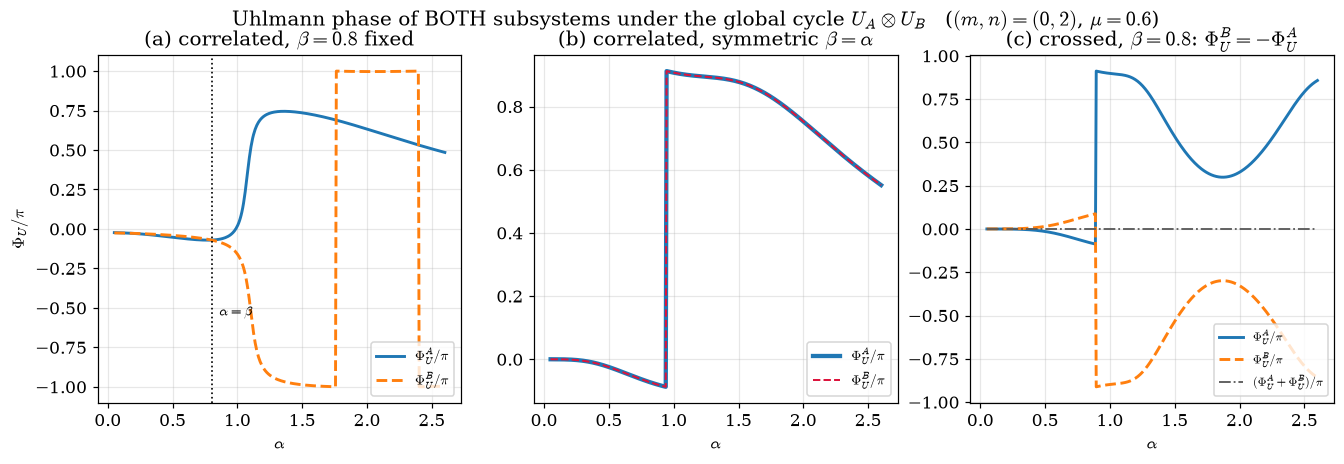

In [28]:

# ============================================================
# Celda 27 — Figura 8: fase de Uhlmann de A y de B bajo el ciclo global
# ============================================================
def figura8():
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.1))
    alphas = np.linspace(0.05, 2.6, 400)
    m, n, mu = 0, 2, 0.6

    # (a) correlacionada, beta fijo distinto de alpha
    beta = 0.8
    rs = [correlated_params(mu, a, beta, m, n) for a in alphas]
    A = np.array([uhlmann_phase_general(r[0], r[2], r[3])/np.pi for r in rs])
    B = np.array([uhlmann_phase_general(r[1], r[2], r[4])/np.pi for r in rs])
    axes[0].plot(alphas, A, lw=1.9, label=r"$\Phi_U^{A}/\pi$")
    axes[0].plot(alphas, B, lw=1.9, ls="--", label=r"$\Phi_U^{B}/\pi$")
    axes[0].axvline(beta, color="k", ls=":", lw=1.1)
    axes[0].text(beta + 0.06, -0.55, r"$\alpha=\beta$", fontsize=9)
    axes[0].set_title(rf"(a) correlated, $\beta={beta}$ fixed")
    axes[0].set_xlabel(r"$\alpha$"); axes[0].set_ylabel(r"$\Phi_U/\pi$")
    axes[0].legend(fontsize=9, loc="lower right")

    # (b) correlacionada simétrica beta = alpha
    rs = [correlated_params(mu, a, a, m, n) for a in alphas]
    A = np.array([uhlmann_phase_general(r[0], r[2], r[3])/np.pi for r in rs])
    B = np.array([uhlmann_phase_general(r[1], r[2], r[4])/np.pi for r in rs])
    axes[1].plot(alphas, A, lw=2.8, label=r"$\Phi_U^{A}/\pi$")
    axes[1].plot(alphas, B, lw=1.3, ls="--", color="crimson",
                 label=r"$\Phi_U^{B}/\pi$")
    axes[1].set_title(r"(b) correlated, symmetric $\beta=\alpha$")
    axes[1].set_xlabel(r"$\alpha$")
    axes[1].legend(fontsize=9, loc="lower right")

    # (c) cruzada: antisimetría exacta
    beta = 0.8
    rs = [crossed_params(mu, a, beta, m, n) for a in alphas]
    A = np.array([uhlmann_phase_general(r[0], r[2], r[3])/np.pi for r in rs])
    B = np.array([uhlmann_phase_general(r[1], r[2], r[4])/np.pi for r in rs])
    axes[2].plot(alphas, A, lw=1.9, label=r"$\Phi_U^{A}/\pi$")
    axes[2].plot(alphas, B, lw=1.9, ls="--", label=r"$\Phi_U^{B}/\pi$")
    axes[2].plot(alphas, A + B, lw=1.2, color="0.35", ls="-.",
                 label=r"$(\Phi_U^{A}+\Phi_U^{B})/\pi$")
    axes[2].set_title(rf"(c) crossed, $\beta={beta}$: $\Phi_U^B=-\Phi_U^A$")
    axes[2].set_xlabel(r"$\alpha$")
    axes[2].legend(fontsize=8, loc="lower right")

    fig.suptitle(r"Uhlmann phase of BOTH subsystems under the global cycle "
                 r"$U_A\otimes U_B$   ($(m,n)=(0,2)$, $\mu=0.6$)")
    savefig(fig, "fig8_uhlmann_subsystem_B")
    plt.show()
    return fig

figura8();



## 15.3 Singularidades nodales de Uhlmann del subsistema $B$

La condición de singularidad se deduce igual que para $A$ (Sec. 10), pero con
las cantidades propias de $B$. Un cero genuino de
$$
Z_U^B=(-1)^{\omega_B}\cos(\pi b_B)-i\,\frac{\omega_B(1-2p_B)}{b_B}\sin(\pi b_B),
\qquad
b_B=\omega_B\sqrt{\frac{p_B(1-p_B)}{\det\rho_B}},
$$
exige que se anulen a la vez su parte real y su parte imaginaria. Como
$\cos(\pi b_B)=0\Rightarrow\sin(\pi b_B)\neq0$, hace falta que se anule
además el factor $(1-2p_B)$. Por tanto

$$
\boxed{\;p_B=\tfrac12\;,\qquad \big|b_B\big|=k+\tfrac12,\quad k\in\mathbb{Z}_{\ge0}\;}
$$

**Torre de concurrencias: idéntica a la de $A$.** En $p_B=1/2$, y usando la
isoespectralidad $\det\rho_B=\det\rho_A=(C/2)^2$,
$$
|b_B|=\frac{|\omega_B|}{C}=\frac{\Delta}{C}
\quad\Longrightarrow\quad
C_k=\frac{2\Delta}{2k+1},\qquad k=\Delta,\Delta+1,\dots
$$
El resultado es el **mismo tower** $C_k$ que en la Ec. (64), porque
$|\omega_B|=|\omega_A|=\Delta$ en ambas familias (incluso en la cruzada, donde
$\omega_B=-\Delta$: sólo interviene el valor absoluto) y porque la
concurrencia es **compartida** por los dos subsistemas.

**Pero la localización es distinta.** Los nodos de $B$ viven sobre la curva
$p_B=1/2$, que en general **no coincide** con $p_A=1/2$. Para la familia
correlacionada con $\beta$ fijo, escribiendo $G=g_{mn}(\alpha)$,
$H=h_{mn}(\beta)$, la condición $p_B=1/2$ es
$$
2(1-\mu^2)(1-H^2)\;=\;1+2\mu\sqrt{1-\mu^2}\,G\,H ,
$$
que se resuelve para $\mu$ a cada $\alpha$. En el caso simétrico $H=G$ se
reduce exactamente a $\mu=\nu(1-2q)$ de la Ec. (65), como debe ser.

**Criterio de existencia: controlado por $\beta$, no por $\alpha$.** Evaluando
el miembro izquierdo menos el derecho en $\mu=0$ se obtiene $1-2H^2$, y en
$\mu=1$ se obtiene $-1$. Luego existe raíz en $(0,1)$ si y sólo si
$$
|h_{mn}(\beta)|^2<\tfrac12
\quad\Longleftrightarrow\quad
\beta<\alpha_g(m,n),
$$
**independientemente de $\alpha$**. Esto contrasta de forma marcada con $A$,
cuya condición es $\alpha\le\alpha_g$. Consecuencia geométrica:

* los nodos de $A$ **se acumulan** en el punto finito
  $(\mu,\alpha)\to(0,\alpha_g)$;
* los nodos de $B$ (con $\beta$ fijo $<\alpha_g$) **no se acumulan a $\alpha$
  finito**: la curva $p_B=1/2$ atraviesa todo el plano y
  $\alpha_k\to\infty$ cuando $k\to\infty$. El punto de acumulación de $B$ está
  en la dirección $\beta$, que aquí se mantiene fija.

En el caso simétrico $\beta=\alpha$ ambas estructuras coinciden y se recupera
exactamente la Fig. 5. Por eso la figura siguiente usa $\beta$ fijo $\neq\alpha$:
es el único régimen en el que la diferencia es visible.


In [29]:

# ============================================================
# Celda 28 — Curvas p=1/2 y coordenadas nodales de A y de B
# ============================================================
def corr_p_and_C(mu, alpha, beta, m, n):
    """(p_A, p_B, C) de la familia correlacionada con beta != alpha."""
    pA, pB, C, _, _ = correlated_params(mu, alpha, beta, m, n)
    return pA, pB, C

def mu_half_curve(alpha, beta, m, n, side):
    """Resuelve p_side(mu; alpha) = 1/2 en mu. Devuelve None si no hay solucion."""
    i = 0 if side == 'A' else 1
    f = lambda mu: corr_p_and_C(mu, alpha, beta, m, n)[i] - 0.5
    lo, hi = 1e-9, 1 - 1e-9
    if f(lo)*f(hi) > 0:
        return None
    return brentq(f, lo, hi, xtol=1e-13)

def C_on_half_curve(alpha, beta, m, n, side):
    """Concurrencia a lo largo de la curva p_side = 1/2."""
    mu = mu_half_curve(alpha, beta, m, n, side)
    if mu is None:
        return None, None
    return mu, corr_p_and_C(mu, alpha, beta, m, n)[2]

def nodal_alphas(k, beta, m, n, side, amax=8.0, ngrid=900):
    """alpha_k: sobre la curva p_side=1/2, donde C alcanza C_k = 2*Delta/(2k+1)."""
    D = n - m
    Ck = nodal_Ck(k, D)
    def f(a):
        _, C = C_on_half_curve(a, beta, m, n, side)
        return np.nan if C is None else C - Ck
    grid = np.linspace(0.02, amax, ngrid)
    vals = np.array([f(a) for a in grid])
    roots = []
    for i in range(len(grid) - 1):
        if (not np.isnan(vals[i])) and (not np.isnan(vals[i+1])) \
           and np.sign(vals[i]) != np.sign(vals[i+1]):
            roots.append(brentq(f, grid[i], grid[i+1], xtol=1e-12))
    return roots, Ck

# ---- verificacion: en cada nodo, p=1/2, b=k+1/2 y |Z_U| = 0 ----
m, n, beta = 0, 2, 0.8
D = n - m
print(f"(m,n)=({m},{n})  Delta={D}  beta={beta}  alpha_g={alpha_g(m,n):.6f}")
print(f"\n{'lado':>5}{'k':>3}  {'alpha_k':>9}{'mu_k':>9}{'C_k':>9}"
      f"{'p':>12}{'b':>10}{'|Z_U|':>10}")
worst = 0.0
for side in ['A', 'B']:
    for k in nodal_k_range(D):
        for a in nodal_alphas(k, beta, m, n, side)[0]:
            mu, C = C_on_half_curve(a, beta, m, n, side)
            pA, pB, Cc = corr_p_and_C(mu, a, beta, m, n)
            p = pA if side == 'A' else pB
            b = uhlmann_b(p, Cc, D)
            Z = uhlmann_ZU(p, Cc, D)
            worst = max(worst, abs(Z), abs(p - 0.5), abs(abs(b) - (k + 0.5)))
            print(f"{side:>5}{k:3d}  {a:9.5f}{mu:9.5f}{Cc:9.5f}"
                  f"{p:12.9f}{b:10.6f}{abs(Z):10.1e}")
print("\npeor desviacion de (p=1/2, |b|=k+1/2, Z_U=0):", worst)
assert worst < 1e-9


(m,n)=(0,2)  Delta=2  beta=0.8  alpha_g=2.109381

 lado  k    alpha_k     mu_k      C_k           p         b     |Z_U|
    A  0    1.90567  0.19105  0.25000 0.500000000  0.500000   1.1e-14
    A  1    1.05220  0.58299  0.75000 0.500000000  1.500000   6.2e-16


    B  0    5.39407  0.56440  0.25000 0.500000000  0.500000   2.8e-15
    B  1    1.13617  0.62356  0.75000 0.500000000  1.500000   3.5e-16

peor desviacion de (p=1/2, |b|=k+1/2, Z_U=0): 1.107666446508216e-14


In [30]:

# ============================================================
# Celda 29 — Criterio de existencia de nodos de B: lo fija beta, no alpha
# ============================================================
print("Existencia de la curva p_B = 1/2 al variar beta  ((m,n)=(0,2))")
print(f"alpha_g(0,2) = {alpha_g(0,2):.6f}\n")
print(f"{'beta':>6}{'|h_beta|^2':>12}  {'existe p_B=1/2?':>16}   "
      f"{'nodos de B hallados (alpha_k)':>36}")
for beta_t in [0.5, 0.8, 1.5, 2.0, 2.109381, 2.5, 3.0]:
    H2 = g_mn(beta_t, 0, 2)**2
    found = []
    for k in nodal_k_range(2):
        found += nodal_alphas(k, beta_t, 0, 2, 'B', amax=8.0)[0]
    existe = "si" if H2 < 0.5 else "NO"
    txt = ", ".join(f"{a:.3f}" for a in sorted(found)[:4]) if found else "-- ninguno --"
    print(f"{beta_t:6.3f}{H2:12.6f}  {existe:>16}   {txt:>36}")
print("\n=> El criterio es |h_mn(beta)|^2 < 1/2  <=>  beta < alpha_g(m,n),")
print("   INDEPENDIENTE de alpha. Contrasta con A, cuyo criterio es alpha <= alpha_g.")


Existencia de la curva p_B = 1/2 al variar beta  ((m,n)=(0,2))
alpha_g(0,2) = 2.109381

  beta  |h_beta|^2   existe p_B=1/2?          nodos de B hallados (alpha_k)


 0.500    0.020408                si                           1.521, 6.629


 0.800    0.082421                si                           1.136, 5.394


 1.500    0.315175                si                                  2.416


 2.000    0.470588                si                                  0.408


 2.109    0.500000                si                          -- ninguno --
 2.500    0.591296                NO                          -- ninguno --
 3.000    0.680672                NO                          -- ninguno --

=> El criterio es |h_mn(beta)|^2 < 1/2  <=>  beta < alpha_g(m,n),
   INDEPENDIENTE de alpha. Contrasta con A, cuyo criterio es alpha <= alpha_g.


[guardado] figures/fig9_uhlmann_nodes_B.pdf


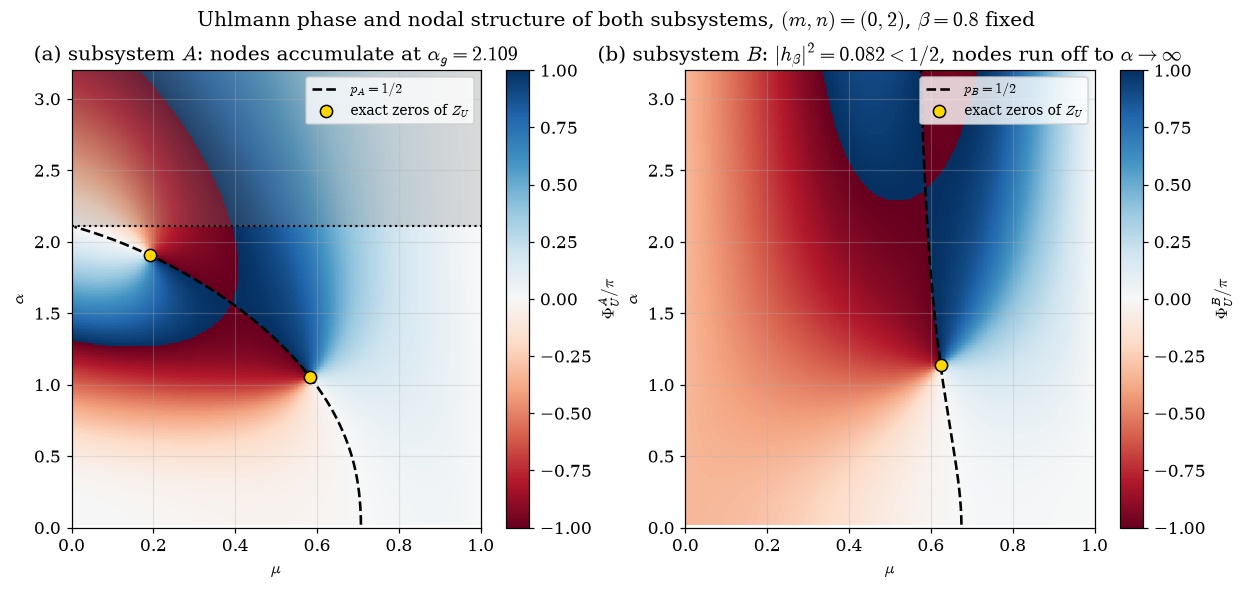

In [31]:

# ============================================================
# Celda 30 — Figura 9: analogo de la Fig. 5 para el subsistema B
# ============================================================
def figura9(m=0, n=2, beta=0.8, amax=3.2, res=300):
    """Mapa de fase de Uhlmann y estructura nodal de AMBOS subsistemas en el
    plano (mu, alpha), con beta fijo distinto de alpha (unico regimen en que
    A y B difieren; si beta = alpha ambos paneles serian la Fig. 5)."""
    D = n - m
    ag = alpha_g(m, n)
    mus = np.linspace(0.001, 0.999, res)
    alphas = np.linspace(0.02, amax, res)
    MU, AL = np.meshgrid(mus, alphas)

    PA = np.zeros_like(MU); PB = np.zeros_like(MU)
    for i in range(res):
        for j in range(res):
            pA, pB, C = corr_p_and_C(MU[i, j], AL[i, j], beta, m, n)
            PA[i, j] = uhlmann_phase_general(pA, C, D)/np.pi
            PB[i, j] = uhlmann_phase_general(pB, C, D)/np.pi

    fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.4))
    aline = np.linspace(0.02, amax, 500)

    for ax, PHI, side in [(axes[0], PA, 'A'), (axes[1], PB, 'B')]:
        im = ax.pcolormesh(MU, AL, PHI, shading="auto", cmap="RdBu",
                           vmin=-1, vmax=1)
        fig.colorbar(im, ax=ax).set_label(rf"$\Phi_U^{{{side}}}/\pi$")
        mm, aa = [], []
        for a in aline:
            mu = mu_half_curve(a, beta, m, n, side)
            if mu is not None:
                mm.append(mu); aa.append(a)
        ax.plot(mm, aa, "k--", lw=1.7, label=rf"$p_{side}=1/2$")
        first = True
        for k in nodal_k_range(D):
            for r in nodal_alphas(k, beta, m, n, side, amax=amax*2.2)[0]:
                if r <= amax:
                    mu, _ = C_on_half_curve(r, beta, m, n, side)
                    ax.plot(mu, r, "o", color="gold", mec="k", ms=8, zorder=5,
                            label=r"exact zeros of $Z_U$" if first else None)
                    first = False
        ax.set_xlabel(r"$\mu$"); ax.set_ylabel(r"$\alpha$")
        ax.set_xlim(0, 1); ax.set_ylim(0, amax)
        ax.legend(loc="upper right", fontsize=9)

    axes[0].axhline(ag, color="k", ls=":", lw=1.4)
    axes[0].fill_between([0, 1], ag, amax, color="gray", alpha=0.25)
    axes[0].set_title(rf"(a) subsystem $A$: nodes accumulate at $\alpha_g={ag:.3f}$")
    H2 = g_mn(beta, m, n)**2
    axes[1].set_title(rf"(b) subsystem $B$: $|h_\beta|^2={H2:.3f}<1/2$, "
                      rf"nodes run off to $\alpha\to\infty$")
    fig.suptitle(r"Uhlmann phase and nodal structure of both subsystems, "
                 rf"$(m,n)=({m},{n})$, $\beta={beta}$ fixed")
    savefig(fig, "fig9_uhlmann_nodes_B")
    plt.show()
    return fig

figura9();



**Lectura de la Fig. 9.** Los dos paneles comparten la misma torre de
concurrencias nodales $C_k=2\Delta/(2k+1)$ y el mismo valor de la concurrencia
en cada punto del plano, pero su **topología nodal es distinta**:

* En **(a)** la curva $p_A=1/2$ se dobla y termina en $(\mu,\alpha)=(0,\alpha_g)$;
  los ceros de $Z_U^A$ se apiñan hacia ese punto de acumulación finito, y la
  franja $\alpha>\alpha_g$ (gris) no puede contener ninguno.
* En **(b)** la curva $p_B=1/2$ es casi **vertical** y atraviesa todo el rango
  de $\alpha$: como el criterio de existencia sólo depende de $\beta$, no hay
  ninguna frontera horizontal, y los ceros de $Z_U^B$ se van separando hacia
  $\alpha\to\infty$ en vez de acumularse.

Es decir: **la misma concurrencia produce dos estructuras de singularidades
geométricamente diferentes en los dos lados del mismo estado entrelazado.**



---

# 15.4 El ciclo **sólo** en $A$: qué le ocurre exactamente a $B$

Restringimos ahora la evolución a $U=e^{-i a_A^\dagger a_A\phi}\otimes I_B$,
sin rotar $B$, y preguntamos por el efecto sobre la geometría de Uhlmann de
$B$. Hay que separar dos objetos que es fácil confundir:

**El estado de $B$ no se mueve.** Ya lo vimos: la traza parcial es cíclica, y
$\rho_B(\phi)=\rho_B(0)$ exactamente. El camino de $\rho_B$ es un **punto**, no
un lazo. Calculando su holonomía con el algoritmo polar —sin suponer nada— se
obtiene $U_{\rm hol}=\mathbb{1}$ y
$$
\Phi_U^B=\Arg\Tr[\rho_B\,\mathbb 1]=\Arg(1)=0 .
$$
Esto es inevitable: la holonomía de Uhlmann es una holonomía **sobre el camino
de la base**, y aquí el camino es constante. No es una limitación del modelo
sino de qué se le está preguntando.

**Pero la amplitud de purificación de $B$ sí se mueve.** Escribiendo el estado
global como $\ket{\Phi}=\sum_{jk}C_{jk}\ket{j}_A\ket{k}_B$, la matriz $C$ es
literalmente una amplitud de $\rho_B$: con $W_B=C^{T}$ se tiene
$W_BW_B^\dagger=C^TC^*=\rho_B$. Bajo el ciclo local $C\mapsto U_AC$, luego
$$
W_B(\phi)=W_B(0)\,U_A^{T}(\phi).
$$
$\rho_B$ es invariante porque $U_A^T$ es unitaria, pero **la amplitud recorre un
lazo vertical en la fibra sobre el punto fijo $\rho_B$**. Su solapamiento con la
amplitud inicial es, exactamente,
$$
\boxed{\;\Tr\!\big[W_B^\dagger(0)W_B(\phi)\big]
=\Tr\!\big[\rho_A(0)\,U_A(\phi)\big]\;}
$$
(demostración: $W_B^\dagger(0)W_B(\phi)=C^*C^TU_A^T$ y $C^*C^T=\rho_A^*$, y
$\Tr[\rho_A^*U_A^T]=\Tr[U_A\rho_A]$). Es decir: **el movimiento de la fibra de
$B$ está gobernado íntegramente por el estado reducido de $A$.** Nótese el
paralelo formal con $\Phi_U=\Arg\Tr[\rho_A(0)U_{\rm hol}]$: aquí aparece la
unitaria **física** en lugar de la holonomía.

Esta fase de tipo Pancharatnam es no nula durante el ciclo, y se cierra en
$\phi=2\pi$ porque $a^\dagger a$ tiene espectro entero y $U_A(2\pi)=\mathbb 1$
exactamente. En el subespacio lógico, si se adopta el convenio del manuscrito
de quedarse sólo con la parte $\sigma_z$ del generador (descartando la fase
escalar $e^{-i(m+n)\phi/2}$), la amplitud de $B$ regresa multiplicada por
$V^T(2\pi)=(-1)^\omega$: un residuo $\mathbb{Z}_2$ que vale $-1$ para $\Delta$
impar. Es el mismo $(-1)^\omega$ que aparece como prefactor en $Z_U$.

**Conclusión.** Con el ciclo estrictamente local sobre $A$, la fase de Uhlmann
de $B$ es cero, y esto es un teorema (no-señalización), no una elección de
modelo. El entrelazamiento se manifiesta en $B$ **no** como movimiento de su
estado sino como movimiento de su purificación. Para obtener una holonomía de
Uhlmann no nula en $B$ hace falta un ciclo que mueva $\rho_B$: el propio de $B$,
o el ciclo global de dos modos.


In [32]:

# ============================================================
# Celda 31 — Ciclo SOLO en A: holonomía de B y movimiento de su amplitud
# ============================================================
def solo_A_analysis(alpha=1.1, beta=0.8, m=0, n=2, mu=0.6, npts=61):
    phis = np.linspace(0, 2*np.pi, npts)

    # camino real de rho_B, proyectado a su soporte de rango 2
    C0 = two_mode_state('correlated', alpha, beta, m, n, mu, 0.0, 'A')
    rA0, rB0 = reduced_states(C0)
    w, V = np.linalg.eigh(rB0)
    P = V[:, np.argsort(w)[::-1][:2]]
    path = []
    for ph in phis:
        _, rB = reduced_states(two_mode_state('correlated', alpha, beta,
                                              m, n, mu, ph, 'A'))
        path.append(P.conj().T @ rB @ P)
    path.append(path[0])

    phiB, valB = uhlmann_discrete(path)
    drift = max(np.abs(p - path[0]).max() for p in path)
    print(f"Ciclo SOLO en A   (alpha={alpha}, beta={beta}, (m,n)=({m},{n}), mu={mu})")
    print(f"  deriva maxima de rho_B a lo largo del ciclo : {drift:.3e}")
    print(f"  |Tr[rho_B U_hol]|                           : {abs(valB):.12f}")
    print(f"  Phi_U^B                                     : {phiB:.3e}   -> CERO")

    # la amplitud de purificacion de B si se mueve
    print("\n  Movimiento de la amplitud de purificacion de B:")
    print(f"  {'phi/2pi':>8} {'Tr[W_B(0)^dag W_B(phi)]':>28} "
          f"{'Tr[rho_A(0) U_A(phi)]':>28} {'dif':>9}")
    lev = np.arange(C0.shape[0])
    worst = 0.0
    for f in [0.0, 0.125, 0.25, 0.5, 0.75, 1.0]:
        ph = 2*np.pi*f
        WBp = two_mode_state('correlated', alpha, beta, m, n, mu, ph, 'A').T
        lhs = np.trace(C0.T.conj().T @ WBp)
        rhs = np.trace(rA0 @ np.diag(np.exp(-1j*lev*ph)))
        worst = max(worst, abs(lhs - rhs))
        print(f"  {f:8.3f} {lhs.real:+11.6f}{lhs.imag:+.6f}j".ljust(40)
              + f"{rhs.real:+11.6f}{rhs.imag:+.6f}j".rjust(28)
              + f" {abs(lhs-rhs):9.1e}")
    print(f"\n  identidad Tr[W_B(0)+W_B(phi)] = Tr[rho_A(0) U_A(phi)] "
          f"verificada a {worst:.1e}")
    assert abs(valB) > 1 - 1e-10 and abs(phiB) < 1e-10 and worst < 1e-12
    return phis, path

solo_A_analysis();


Ciclo SOLO en A   (alpha=1.1, beta=0.8, (m,n)=(0,2), mu=0.6)
  deriva maxima de rho_B a lo largo del ciclo : 7.772e-16
  |Tr[rho_B U_hol]|                           : 1.000000000000
  Phi_U^B                                     : 3.688e-19   -> CERO

  Movimiento de la amplitud de purificacion de B:
   phi/2pi      Tr[W_B(0)^dag W_B(phi)]        Tr[rho_A(0) U_A(phi)]       dif
     0.000   +1.000000+0.000000j                 +1.000000+0.000000j   0.0e+00
     0.125   -0.260182-0.212166j                 -0.260182-0.212166j   1.6e-16
     0.250   +0.112428-0.015561j                 +0.112428-0.015561j   6.2e-17
     0.500   +0.029463-0.000000j                 +0.029463-0.000000j   0.0e+00
     0.750   +0.112428+0.015561j                 +0.112428+0.015561j   6.2e-17
     1.000   +1.000000+0.000000j                 +1.000000+0.000000j   9.9e-32

  identidad Tr[W_B(0)+W_B(phi)] = Tr[rho_A(0) U_A(phi)] verificada a 1.6e-16



### Resumen de la corrección

| ciclo aplicado | $\omega_A$ | $\omega_B$ | $\Phi_U^A$ | $\Phi_U^B$ |
|---|---|---|---|---|
| $U_A\otimes I$ (local en $A$) | $\Delta$ | $0$ | $\neq0$ | $0$ *(teorema de no-señalización)* |
| $I\otimes U_B$ (local en $B$) | $0$ | $\pm\Delta$ | $0$ | $\neq0$ |
| $U_A\otimes U_B$ (**evolución libre global**) | $\Delta$ | $\pm\Delta$ | $\neq0$ | $\neq0$ |

En resumen: la afirmación "el subsistema $B$ tiene fase geométrica nula" sólo
vale para el ciclo estrictamente local sobre $A$, y no debe leerse como que
$\rho_B$ carezca de geometría de Uhlmann. Como $\rho_B$ procede de un PACS
entrelazado, es mixto con $\det\rho_B=(C/2)^2>0$, e **igual que $\rho_A$ porta
una holonomía de Uhlmann no trivial**, con su propia población $p_B$ y su
propio número de enrollamiento $\omega_B$, que en la familia cruzada tiene
**signo opuesto** al de $A$.



## 16. Resumen y cómo reproducir todo

* Todas las fórmulas cerradas de este notebook fueron **contrastadas contra
  un cálculo independiente en espacio de Fock truncado** (secciones 3, 4, 5,
  7) y contra las **Tablas I y II publicadas** (secciones 4 y 10), con
  acuerdo hasta precisión de máquina o hasta el redondeo a 4 decimales del
  artículo original.
* Se identificó y corrigió una ambigüedad tipográfica del manuscrito en el
  prefactor de las Ecs. (27) y (37) (Sección 4): el factor $\Delta!$ va
  fuera de la raíz cuadrada.
* Las 7 figuras y las 2 tablas se guardan automáticamente como PDF/CSV/TeX
  vectoriales en la carpeta `figures/` a medida que se ejecuta el
  notebook. Para regenerar todo de una sola vez basta con reiniciar el
  kernel y ejecutar todas las celdas (`Run All`), o ejecutar la celda
  siguiente, que vuelve a llamar a las siete funciones de figura.


[guardado] figures/fig1_global_berry_vs_alpha.pdf


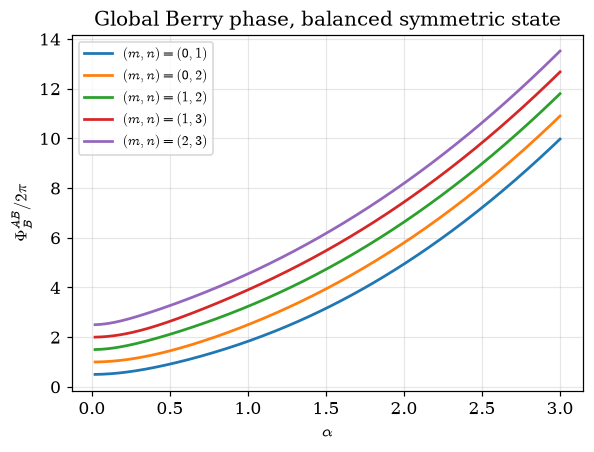

[guardado] figures/fig2_discrete_mn_dependence.pdf


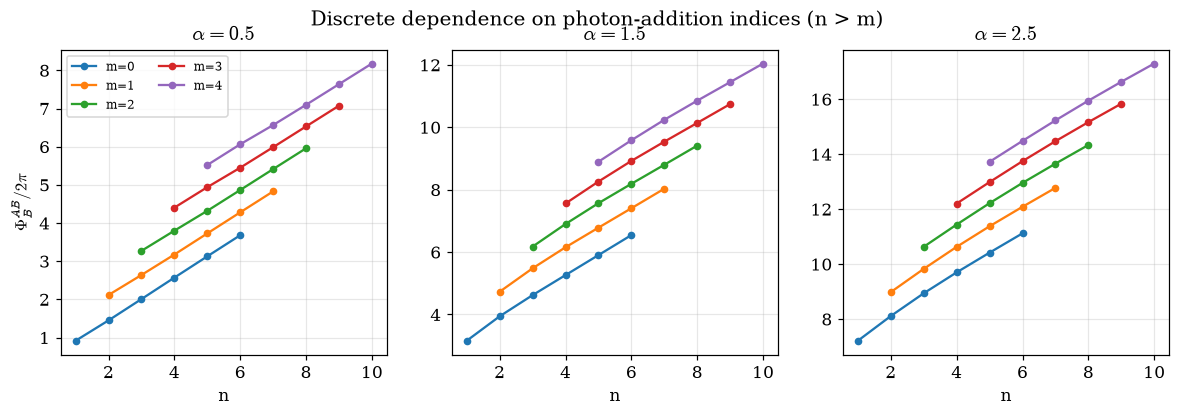

[guardado] figures/fig3_berry_vs_chi.pdf


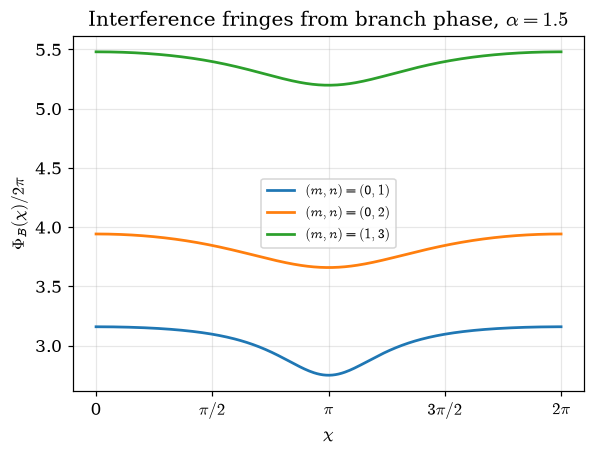

[guardado] figures/fig4_berry_mu_alpha_plane.pdf


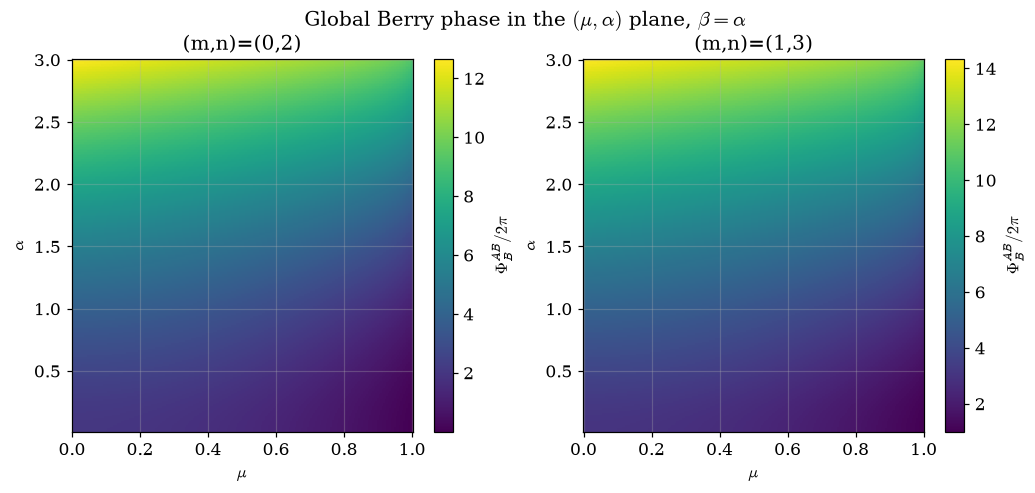

[guardado] figures/fig5_uhlmann_phase_diagram.pdf


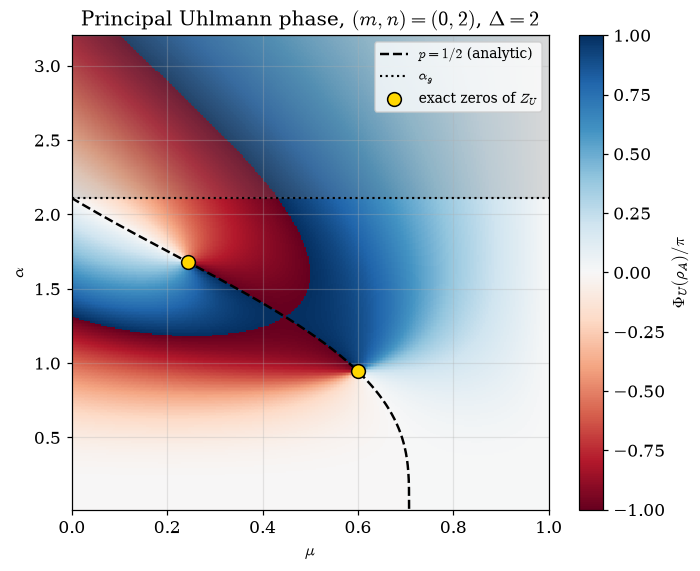

[guardado] figures/fig6_critical_overlap_structure.pdf


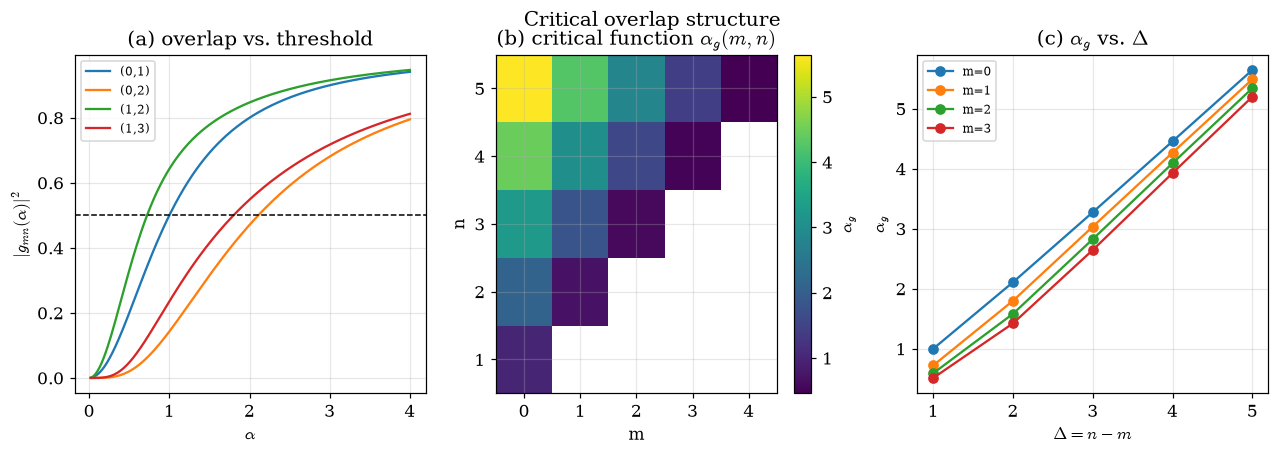

[guardado] figures/fig7_uhlmann_vs_Delta.pdf


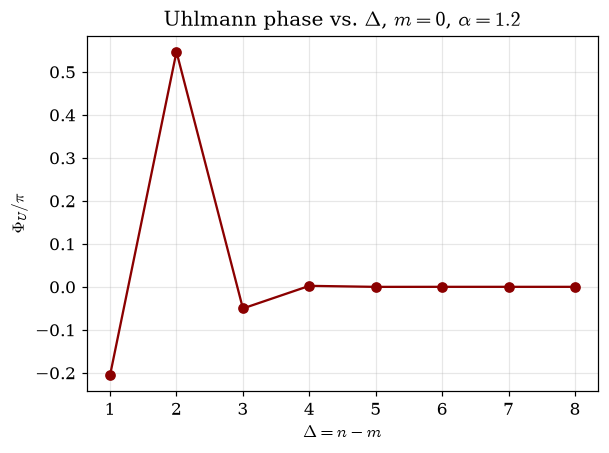

[guardado] figures/fig8_uhlmann_subsystem_B.pdf


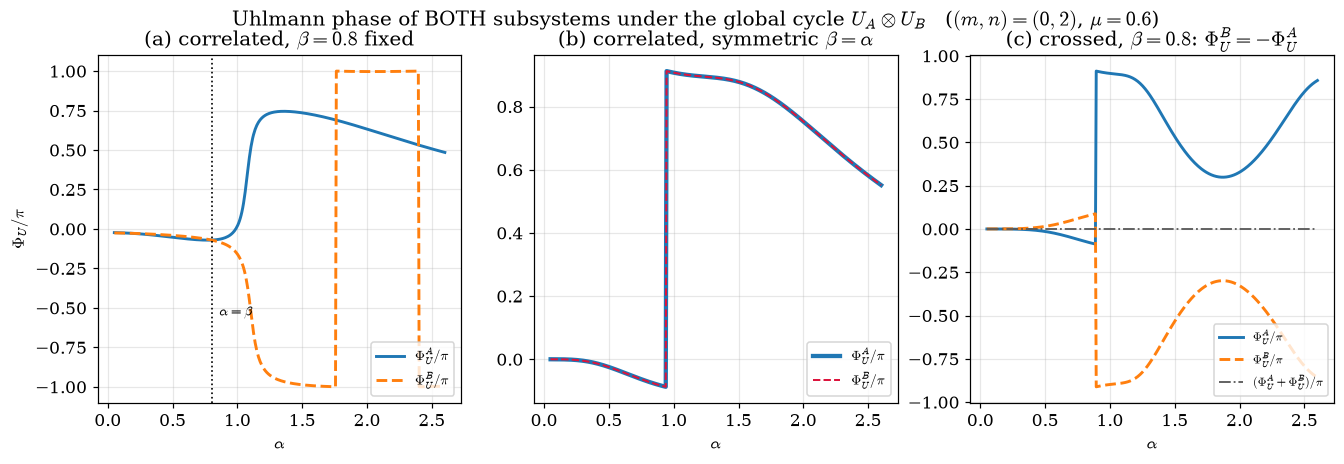

[guardado] figures/fig9_uhlmann_nodes_B.pdf


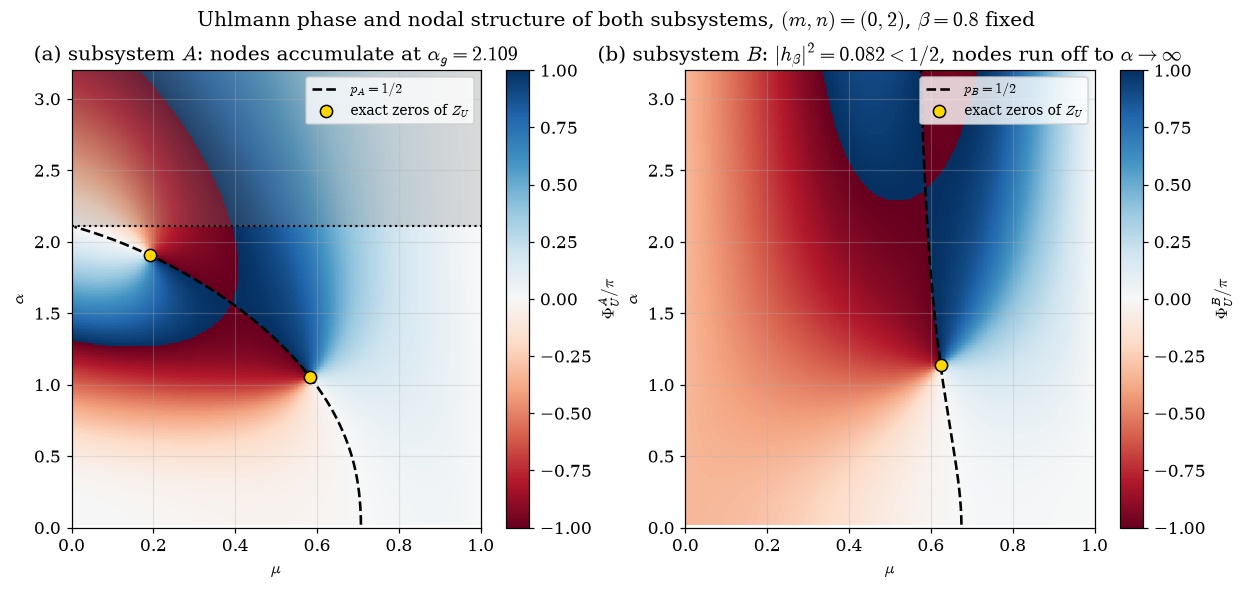


Todas las figuras fueron regeneradas y guardadas en: /home/user/prueba/notebook/figures


In [33]:

# ============================================================
# Celda 21 — Regenerar todas las figuras de una sola vez
# ============================================================
for fn in [figura1, figura2, figura3, figura4, figura5, figura6, figura7, figura8, figura9]:
    fn()
print("\nTodas las figuras fueron regeneradas y guardadas en:", os.path.abspath(FIGDIR))



## Referencias

[1] G. S. Agarwal and K. Tara, *Phys. Rev. A* **43**, 492 (1991).
[2] M. V. Berry, *Proc. R. Soc. Lond. A* **392**, 45 (1984).
[3] A. Uhlmann, *Rep. Math. Phys.* **24**, 229 (1986).
[4] W. K. Wootters, *Phys. Rev. Lett.* **80**, 2245 (1998).
[5] F. A. Domínguez-Serna, F. J. Mendieta-Jiménez, F. Rojas, *Quantum Inf. Process.* **15**, 3121 (2016).
[6] S. Mohammadi Almas, G. Najarbashi, A. Tavana, *Int. J. Theor. Phys.* **61**, 192 (2022).
[7] D.-B. Yang, Y. Chen, F.-L. Zhang, J.-L. Chen, *J. Phys. B* **44**, 075502 (2011).
[8] X. Wang, X.-Y. Hou, Z. Zhou, H. Guo, C.-C. Chien, *SciPost Phys. Core* **6**, 024 (2023).
